In [1]:
import polars as pl
training_data = pl.read_parquet(r"C:\Users\elmaz\AIProject\NASA_Project\data\processed_data\model_ready_train.parquet")


In [2]:
import pandas as pd
# Convert Polars DataFrame to Pandas DataFrame
training_data_pd = training_data.to_pandas()

In [3]:
training_data_pd.columns

Index(['bearing_id', 'step', 'mean_ax', 'rms_ax', 'std_ax', 'skew_ax',
       'kurtosis_ax', 'peak_ax', 'p2p_ax', 'crest_ax', 'shape_ax',
       'impulse_ax', 'mean_ay', 'rms_ay', 'std_ay', 'skew_ay', 'kurtosis_ay',
       'peak_ay', 'p2p_ay', 'crest_ay', 'shape_ay', 'impulse_ay', 'mean_mag',
       'rms_mag', 'std_mag', 'skew_mag', 'kurtosis_mag', 'peak_mag', 'p2p_mag',
       'crest_mag', 'shape_mag', 'impulse_mag', 'health_index', 'regime_label',
       'RUL', 'RUL_pct', 'rms_ax_slope', 'kurtosis_ax_slope', 'rms_ay_slope',
       'kurtosis_ay_slope', 'rms_mag_slope', 'kurtosis_mag_slope',
       'peak_ax_slope', 'peak_ay_slope', 'peak_mag_slope'],
      dtype='str')

In [4]:
training_data_pd.head(2)

,bearing_id,step,mean_ax,rms_ax,std_ax,skew_ax,kurtosis_ax,peak_ax,p2p_ax,crest_ax,...,RUL_pct,rms_ax_slope,kurtosis_ax_slope,rms_ay_slope,kurtosis_ay_slope,rms_mag_slope,kurtosis_mag_slope,peak_ax_slope,peak_ay_slope,peak_mag_slope
0,bearing_1,1,-0.000191,0.538710,0.538815,-0.276842,0.409498,1.767,4.097,3.280058,...,99.805825,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000,0.000,0.000000
1,bearing_1,2,0.003091,0.505577,0.505666,-0.081524,0.196925,1.982,3.797,3.920272,...,99.611650,-0.033133,-0.212573,0.013249,0.045065,-0.017244,-0.05977,0.215,0.243,-0.167244


In [5]:
target_column = training_data_pd.pop("RUL_pct")
training_data_pd["RUL_pct"] = target_column
training_data_pd.head(1)

,bearing_id,step,mean_ax,rms_ax,std_ax,skew_ax,kurtosis_ax,peak_ax,p2p_ax,crest_ax,...,rms_ax_slope,kurtosis_ax_slope,rms_ay_slope,kurtosis_ay_slope,rms_mag_slope,kurtosis_mag_slope,peak_ax_slope,peak_ay_slope,peak_mag_slope,RUL_pct
0,bearing_1,1,-0.000191,0.53871,0.538815,-0.276842,0.409498,1.767,4.097,3.280058,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,99.805825


### Data preprocessing

In [6]:
training_data_pd.info()


<class 'pandas.DataFrame'>
RangeIndex: 7534 entries, 0 to 7533
Data columns (total 45 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bearing_id          7534 non-null   str    
 1   step                7534 non-null   int64  
 2   mean_ax             7534 non-null   float32
 3   rms_ax              7534 non-null   float32
 4   std_ax              7534 non-null   float32
 5   skew_ax             7534 non-null   float32
 6   kurtosis_ax         7534 non-null   float32
 7   peak_ax             7534 non-null   float32
 8   p2p_ax              7534 non-null   float32
 9   crest_ax            7534 non-null   float32
 10  shape_ax            7534 non-null   float32
 11  impulse_ax          7534 non-null   float32
 12  mean_ay             7534 non-null   float32
 13  rms_ay              7534 non-null   float32
 14  std_ay              7534 non-null   float32
 15  skew_ay             7534 non-null   float32
 16  kurtosis_ay      

In [7]:
training_data_pd[["regime_label", "bearing_id"]].head(1)

,regime_label,bearing_id
0,healthy,bearing_1


In [8]:
training_data_pd = pd.get_dummies(training_data_pd, columns=['regime_label'], prefix='regime')
training_data_pd.head(5)

,bearing_id,step,mean_ax,rms_ax,std_ax,skew_ax,kurtosis_ax,peak_ax,p2p_ax,crest_ax,...,kurtosis_ay_slope,rms_mag_slope,kurtosis_mag_slope,peak_ax_slope,peak_ay_slope,peak_mag_slope,RUL_pct,regime_critical,regime_healthy,regime_transition
0,bearing_1,1,-0.000191,0.538710,0.538815,-0.276842,0.409498,1.767,4.097,3.280058,...,0.000000,0.000000,0.000000,0.0000,0.0000,0.000000,99.805825,False,True,False
1,bearing_1,2,0.003091,0.505577,0.505666,-0.081524,0.196925,1.982,3.797,3.920272,...,0.045065,-0.017244,-0.059770,0.2150,0.2430,-0.167244,99.611650,False,True,False
2,bearing_1,3,-0.007987,0.542441,0.542488,0.091990,0.036907,1.830,3.598,3.373639,...,-0.035291,0.011276,-0.346324,0.0315,0.1230,-0.136024,99.417476,False,True,False
3,bearing_1,4,0.022698,0.515008,0.514608,-0.020372,0.089857,1.600,3.486,3.106749,...,-0.013109,0.008877,-0.268057,-0.0653,0.1227,-0.113320,99.223301,False,True,False
4,bearing_1,5,0.002741,0.485601,0.485689,0.014214,-0.040428,1.536,3.241,3.163088,...,-0.020945,0.000075,-0.224571,-0.0844,0.1053,-0.113795,99.029126,False,True,False


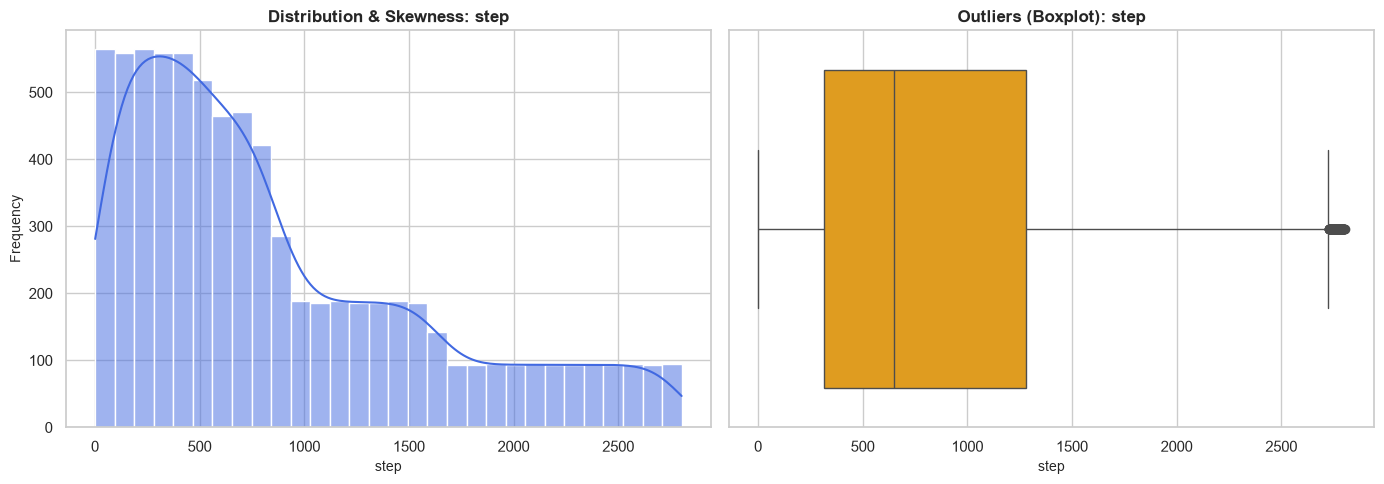

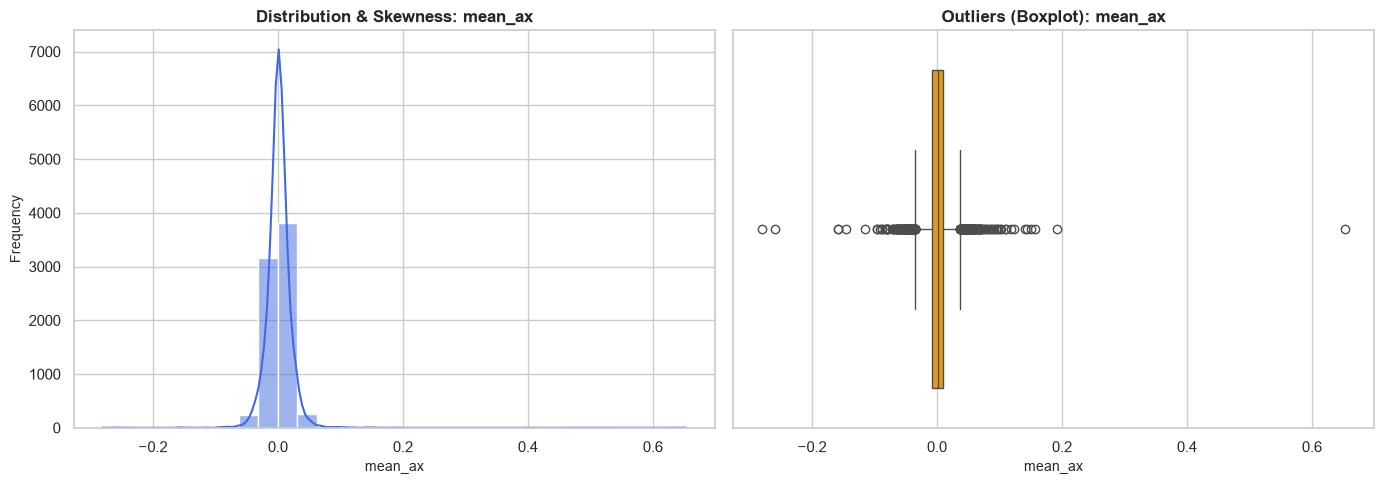

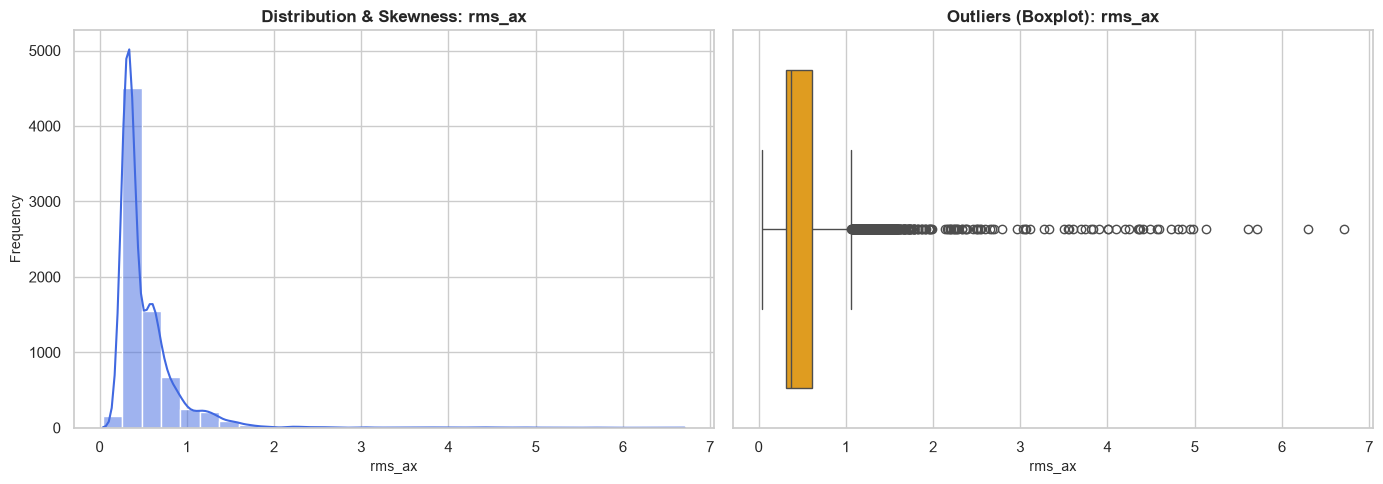

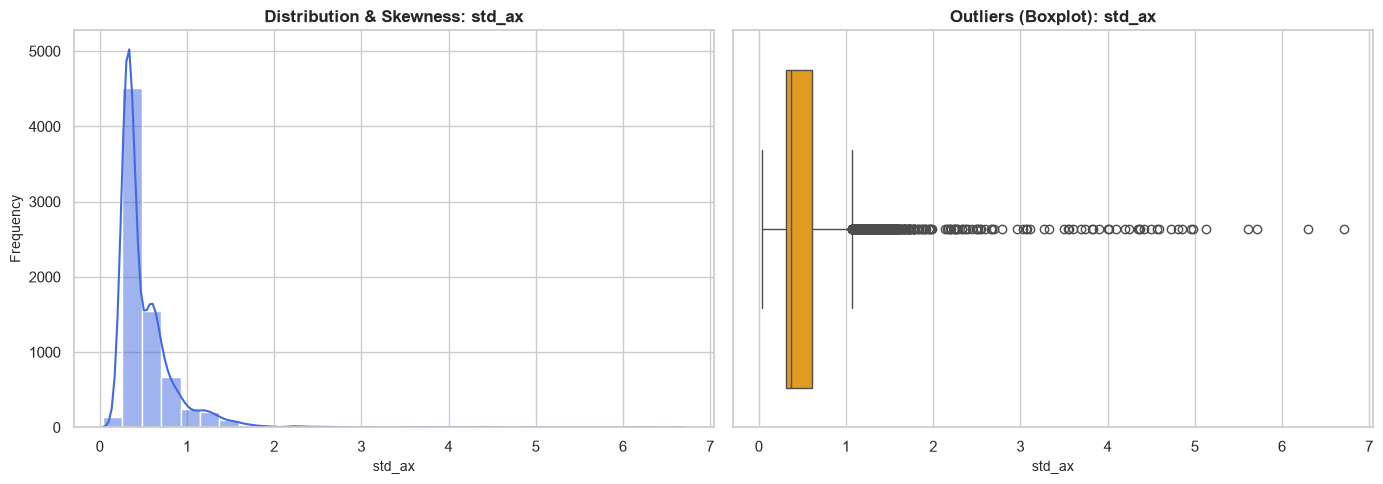

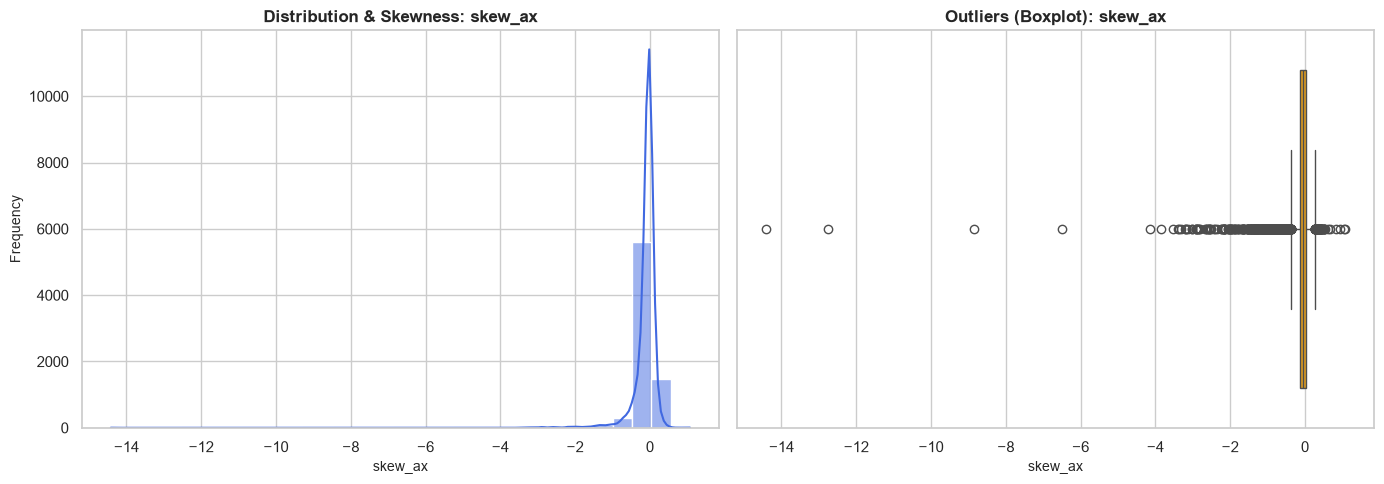

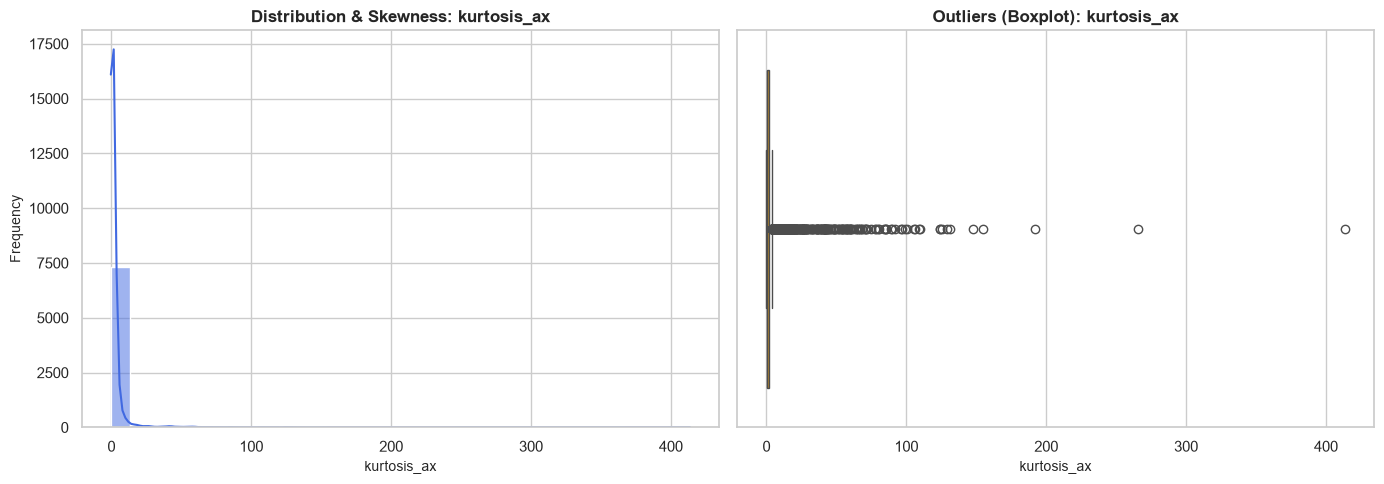

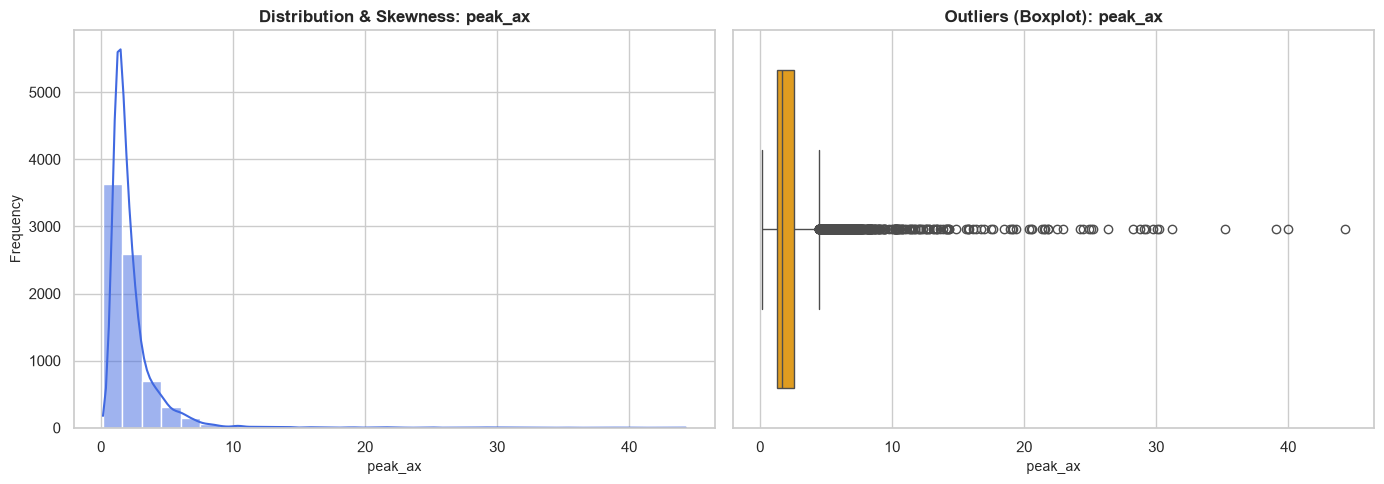

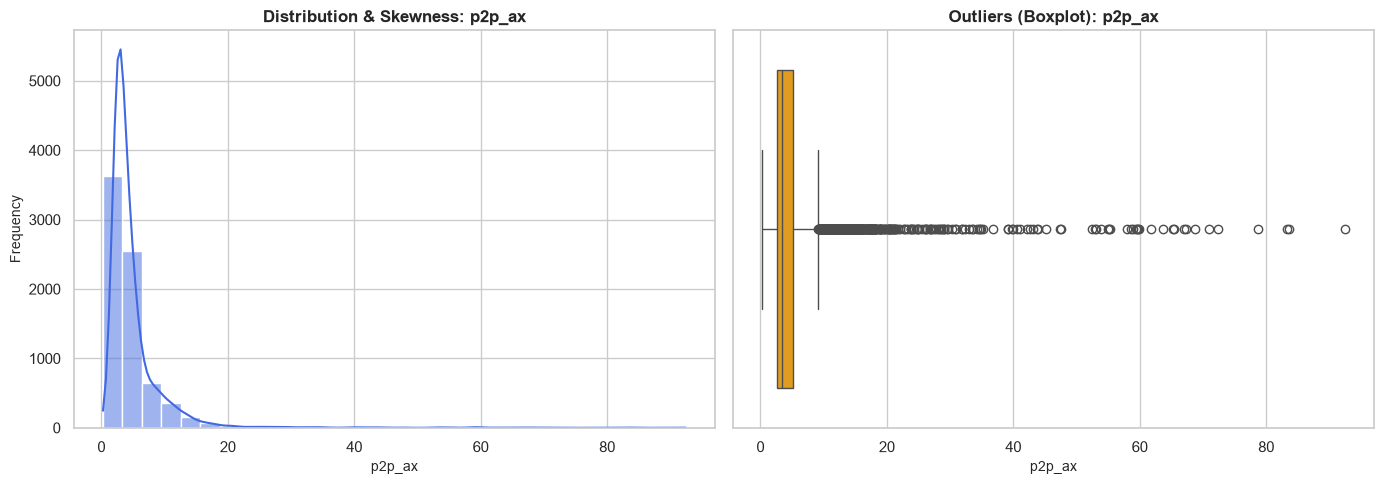

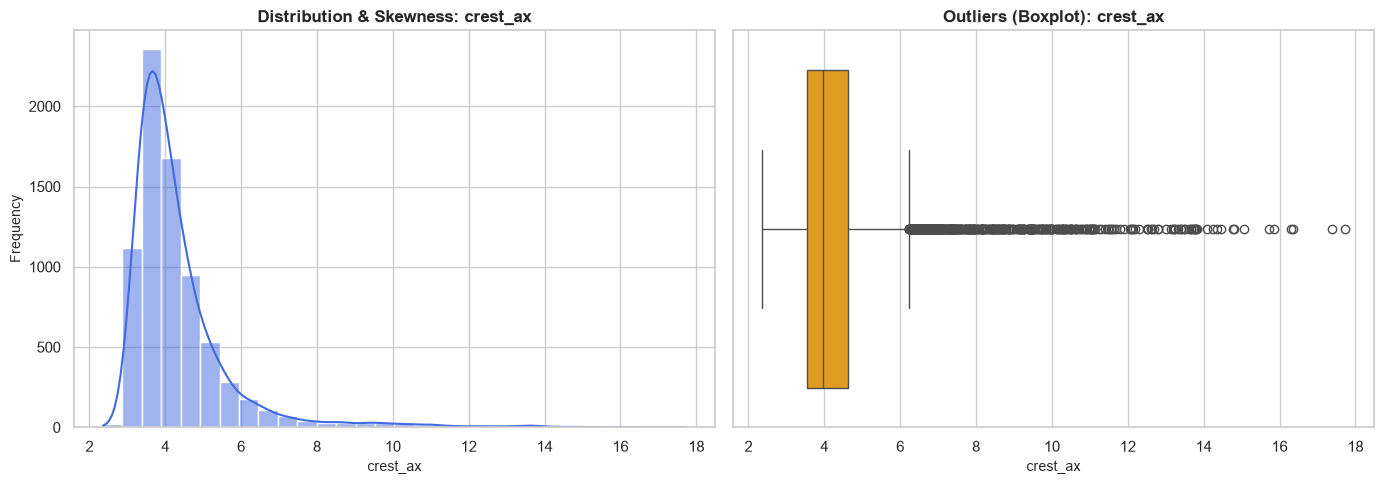

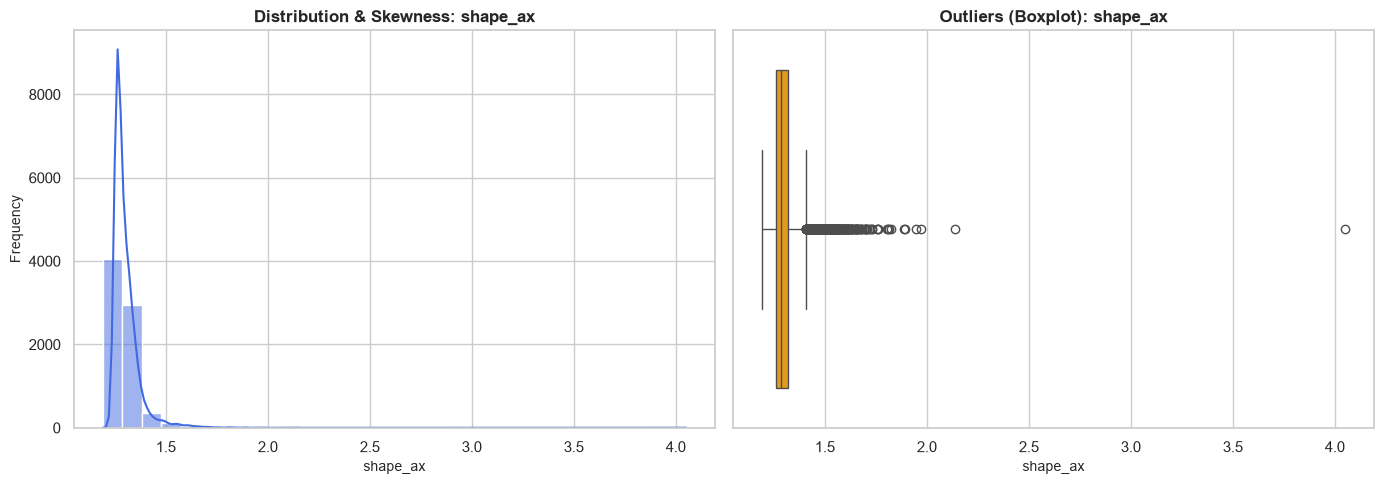

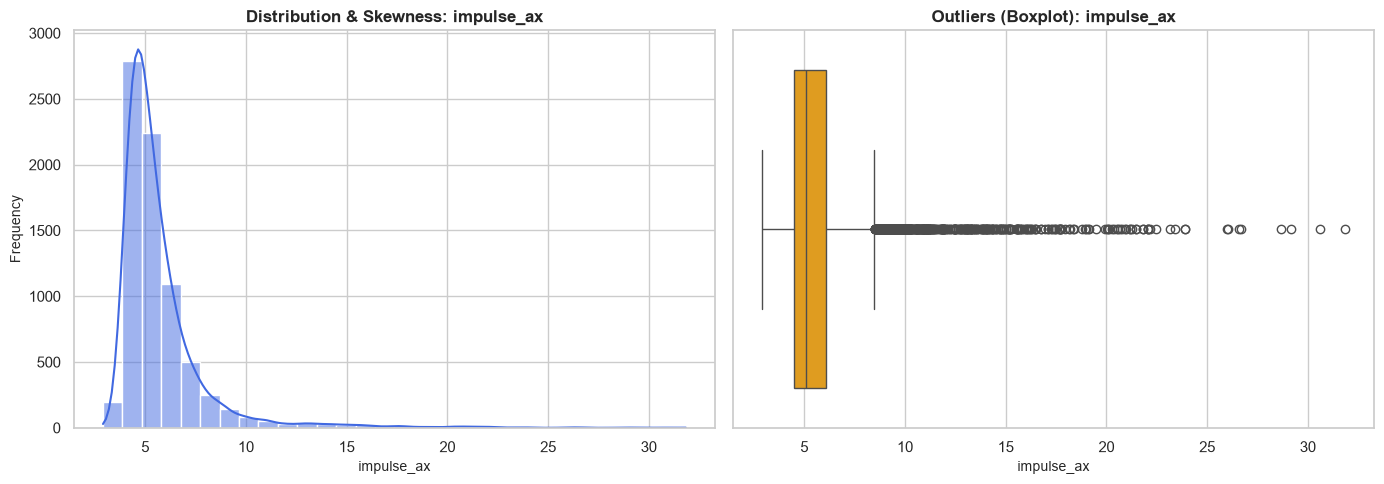

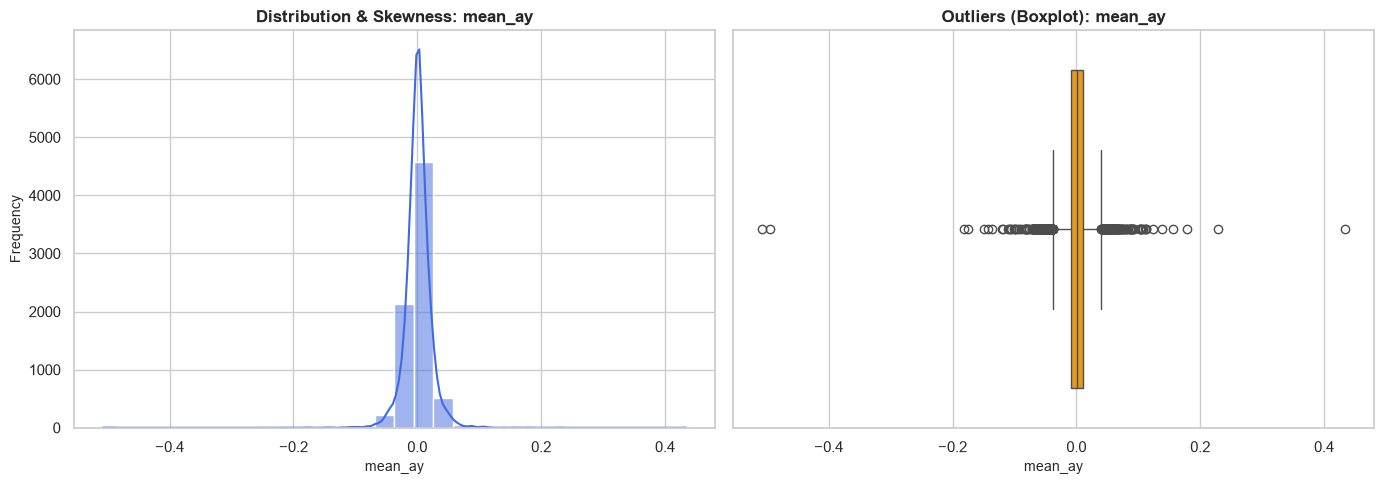

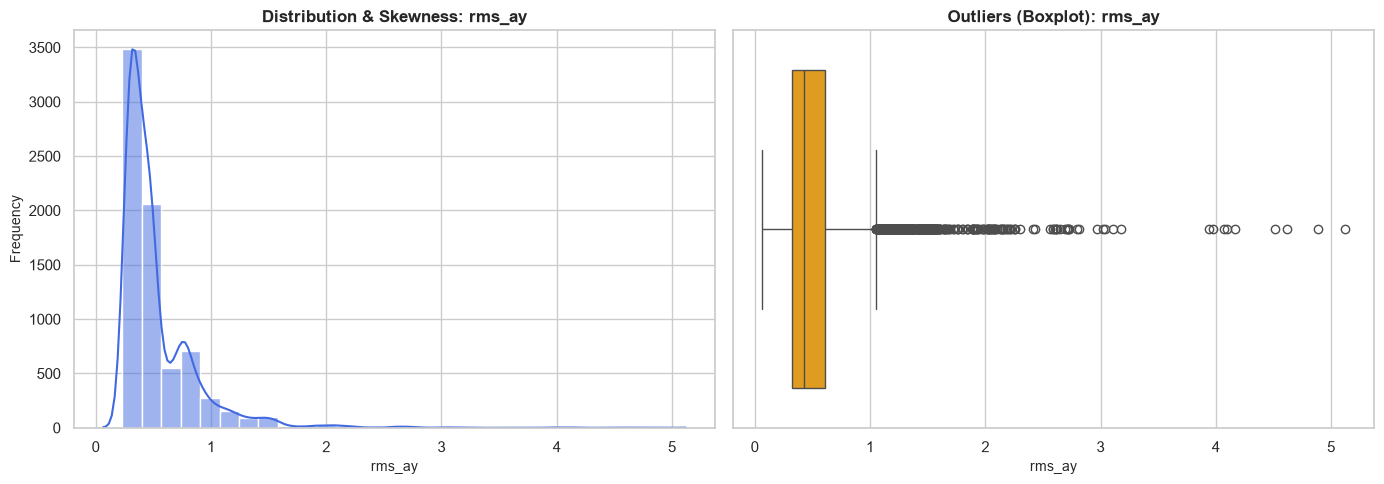

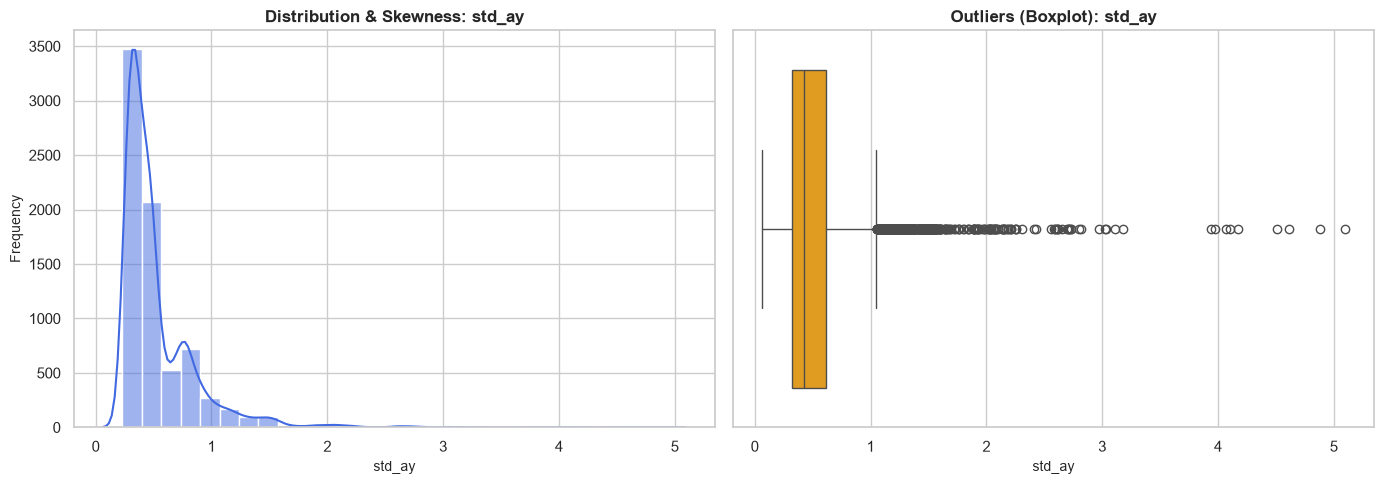

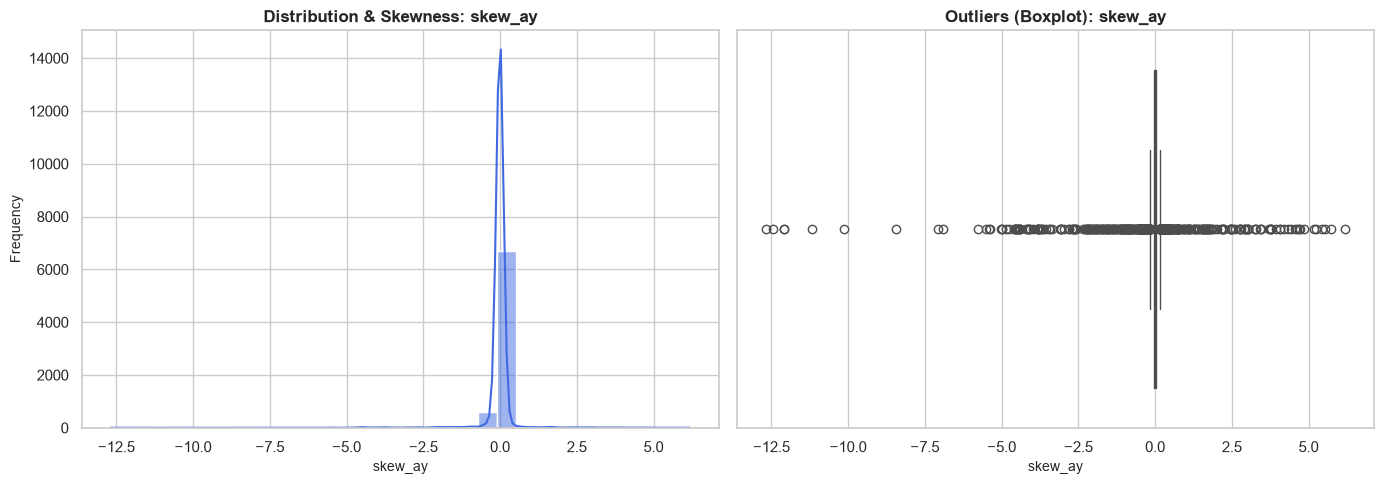

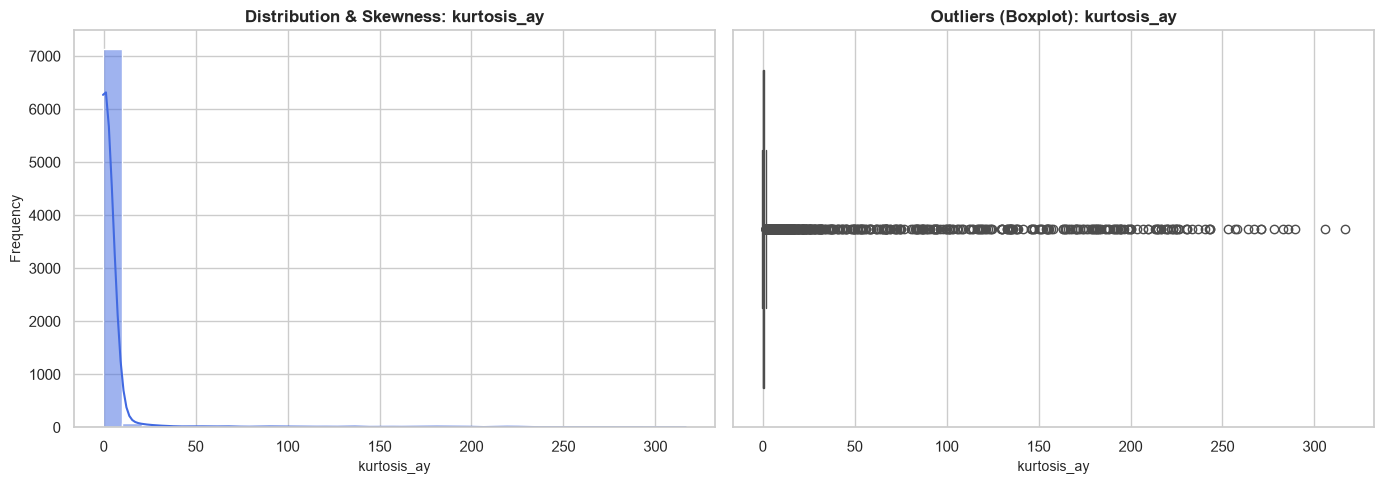

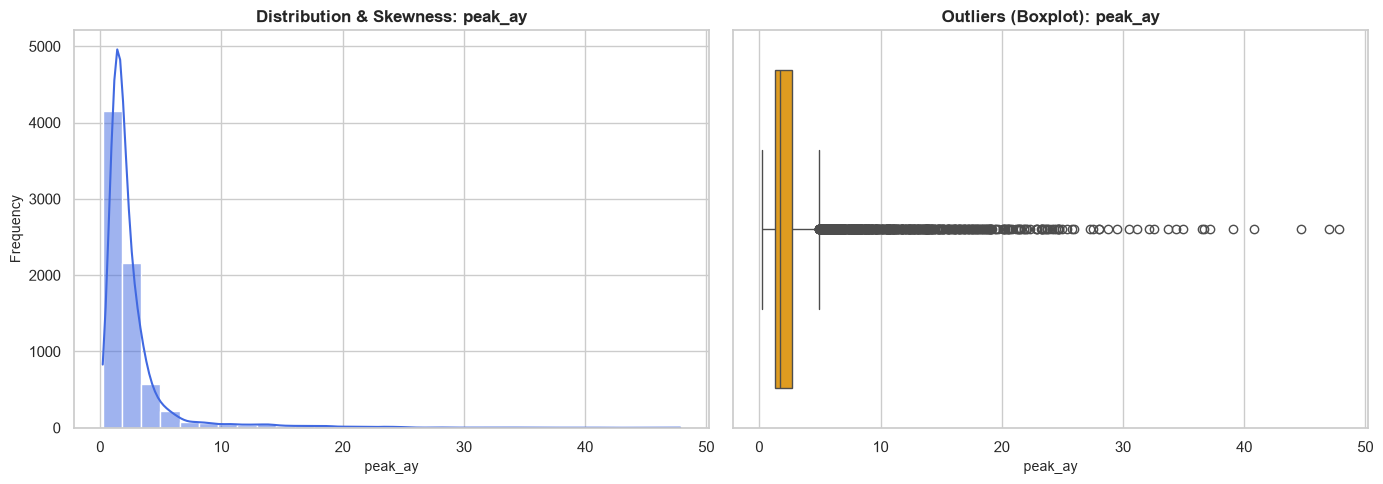

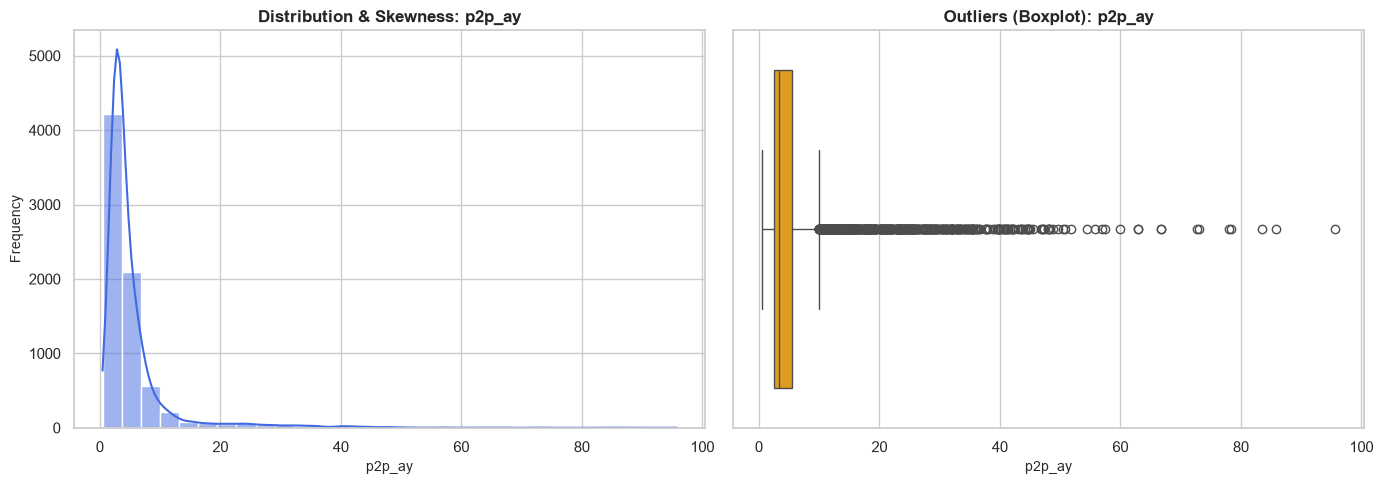

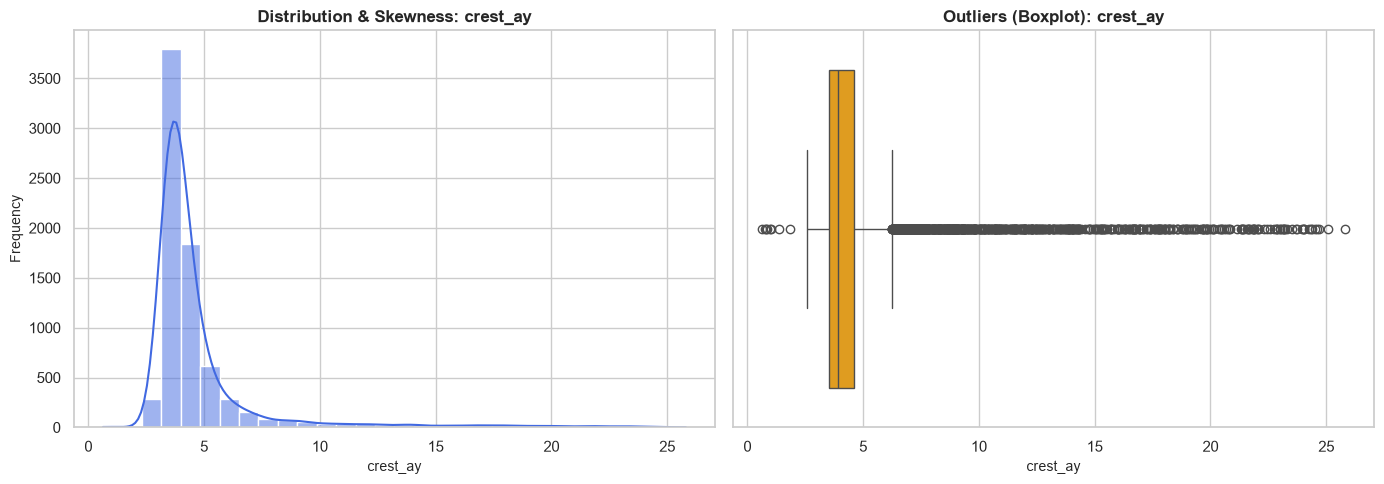

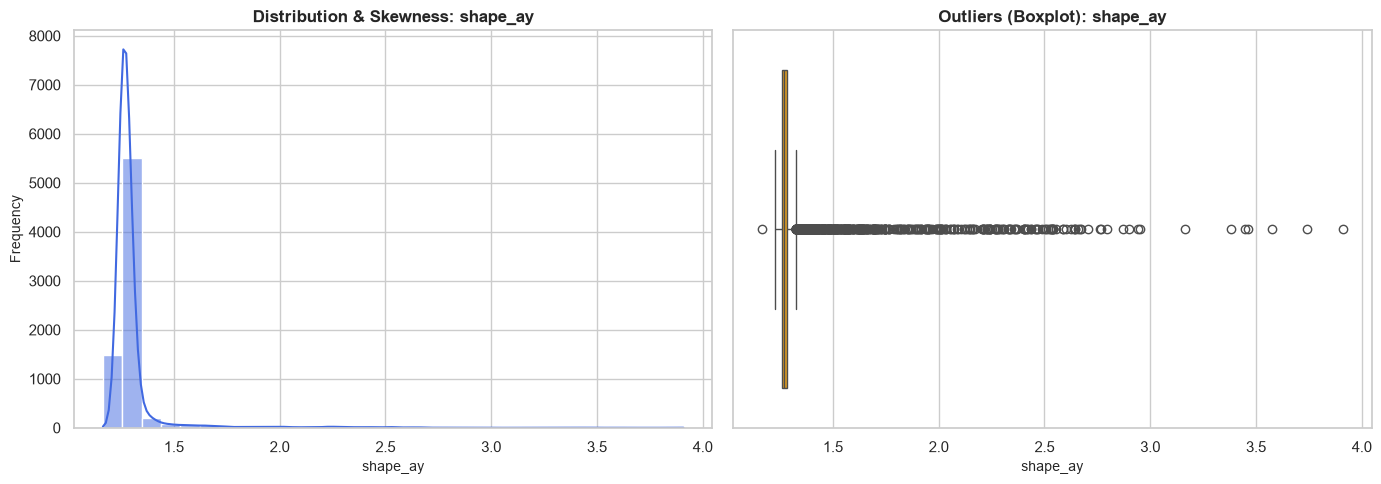

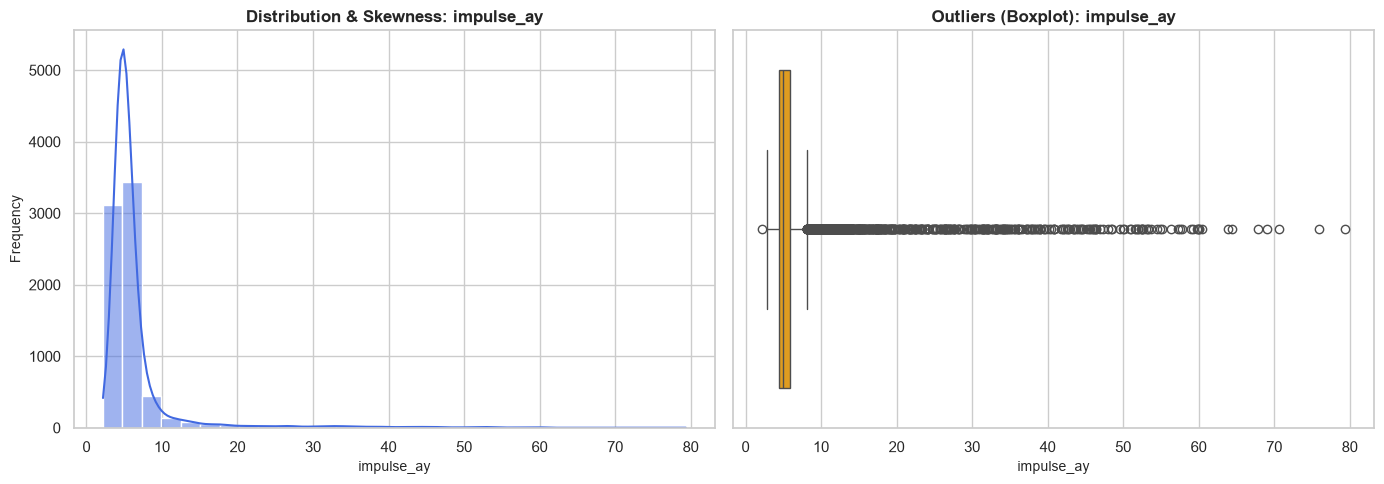

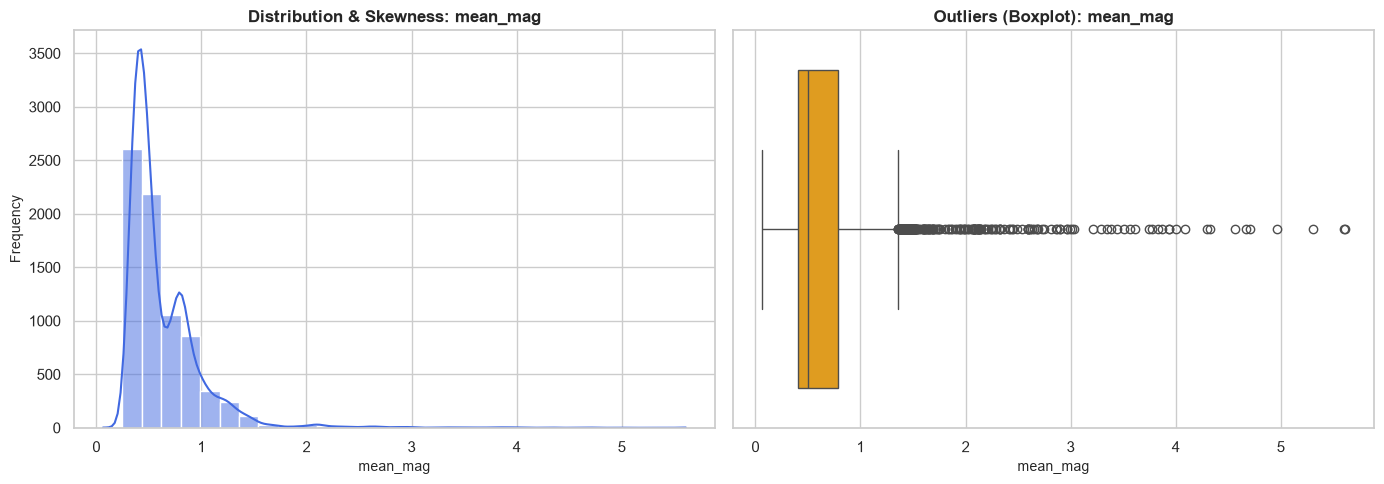

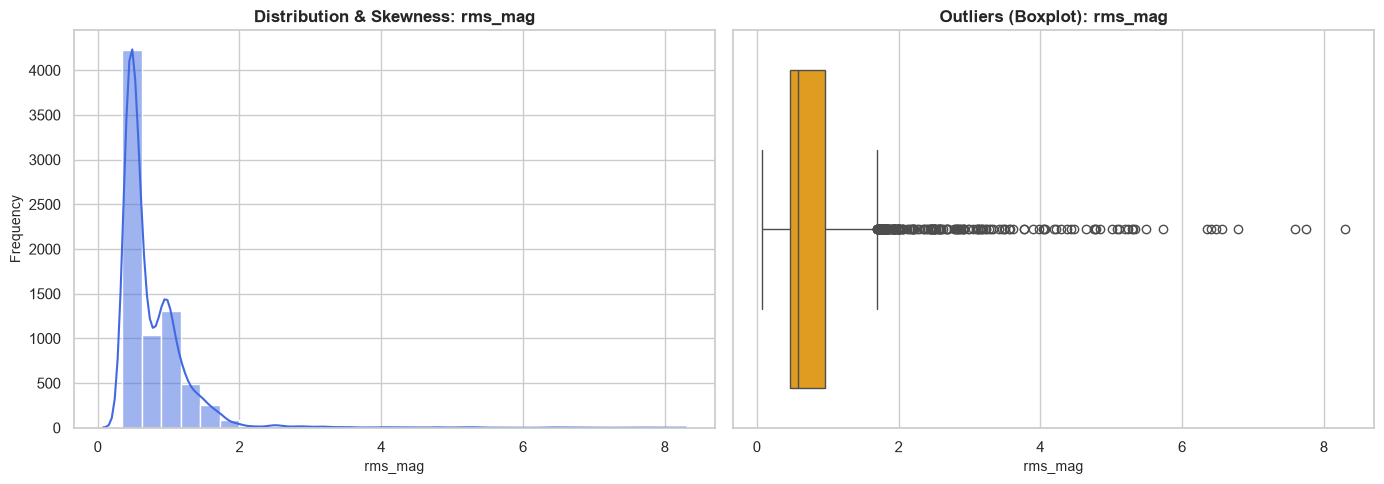

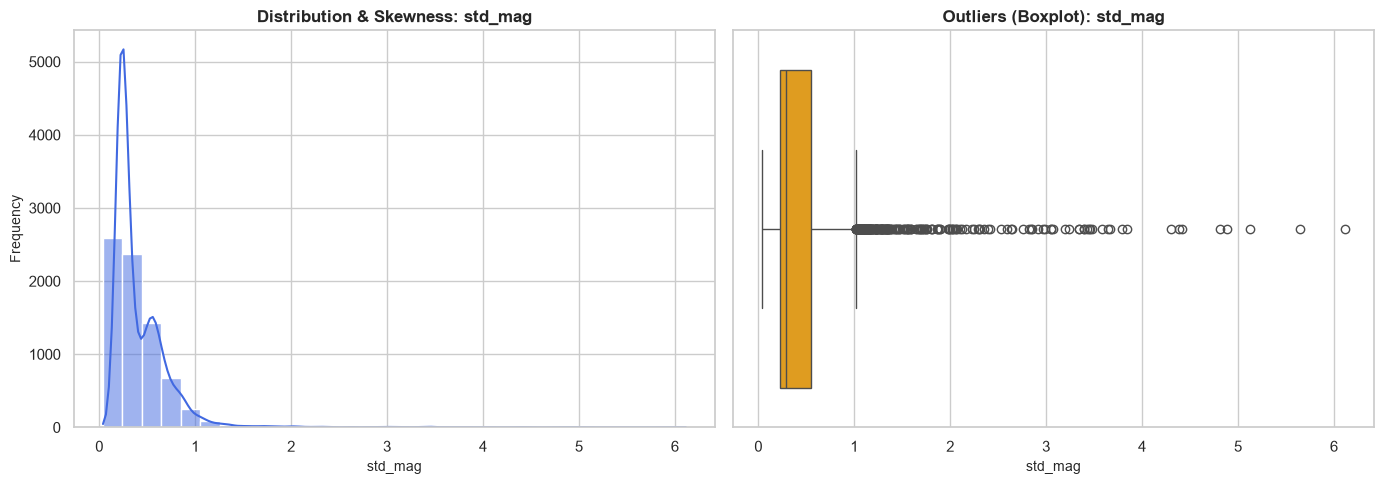

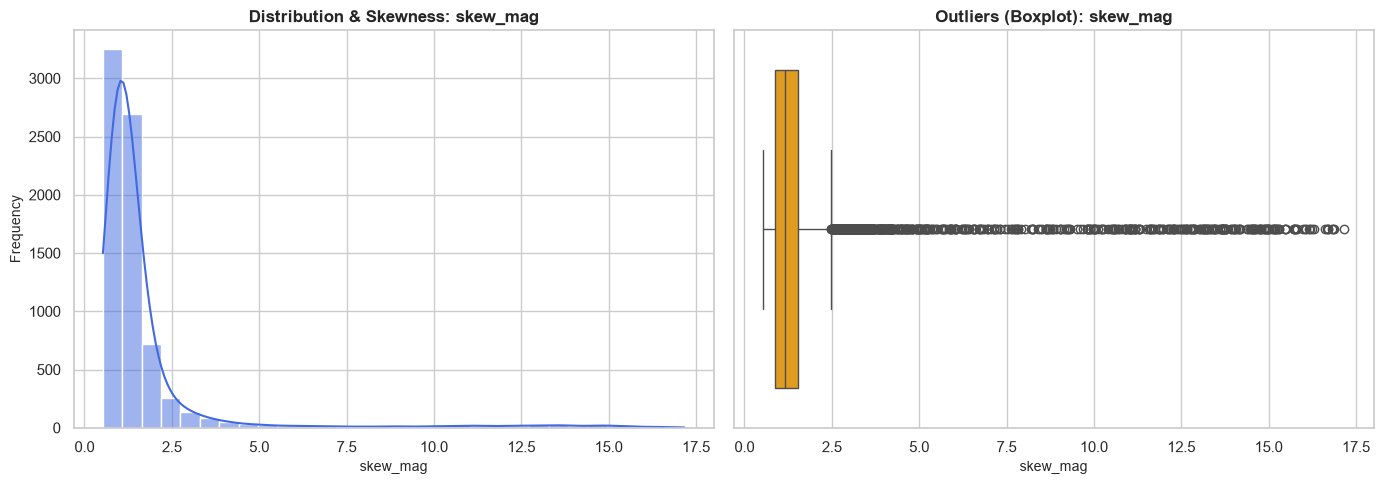

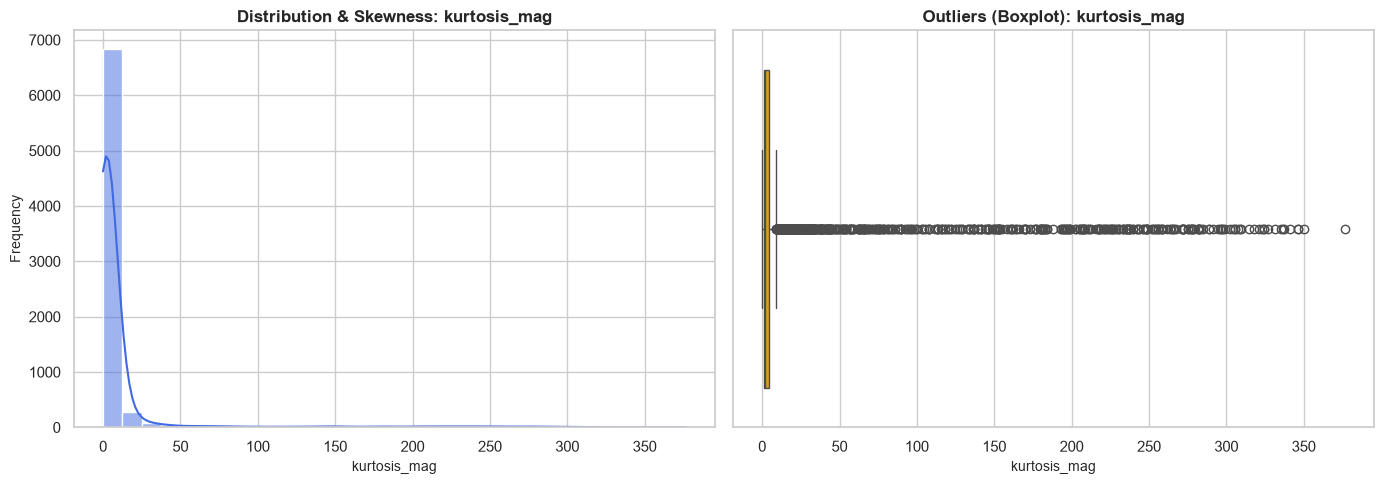

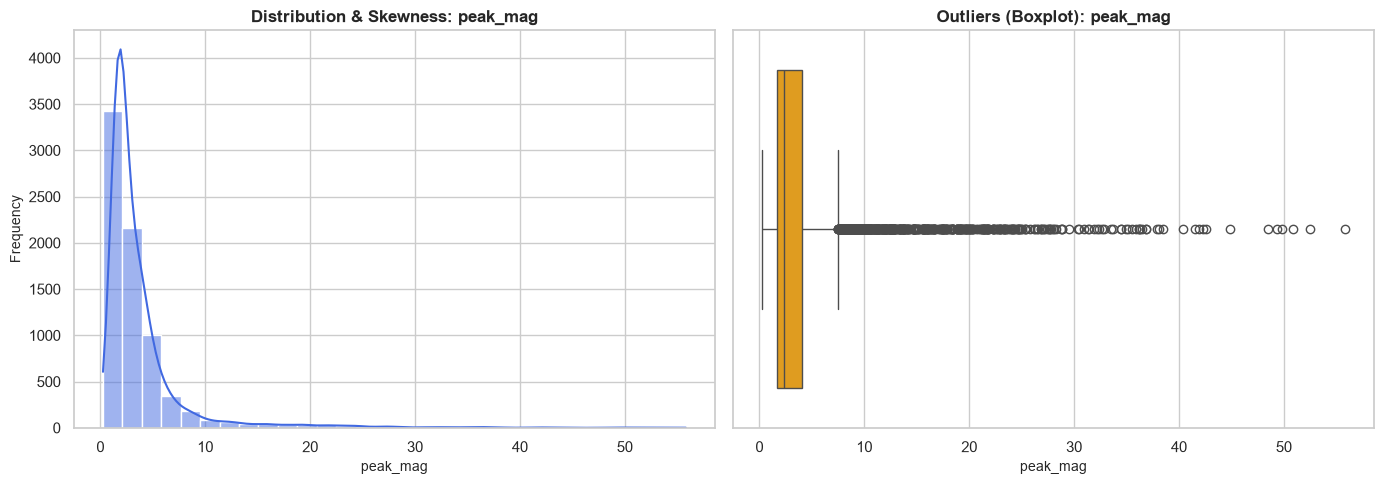

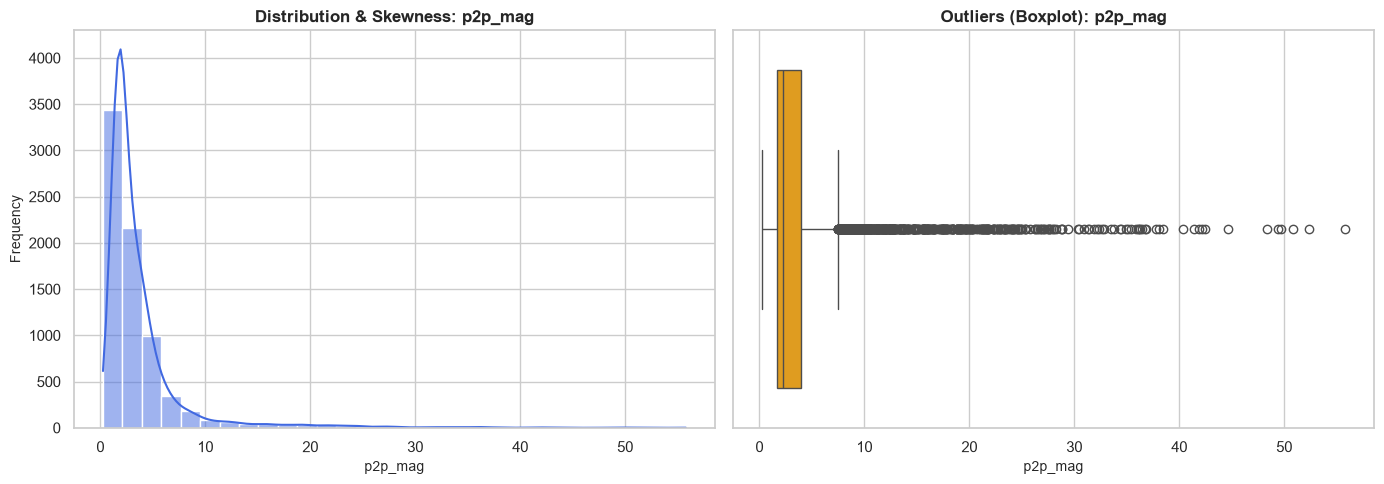

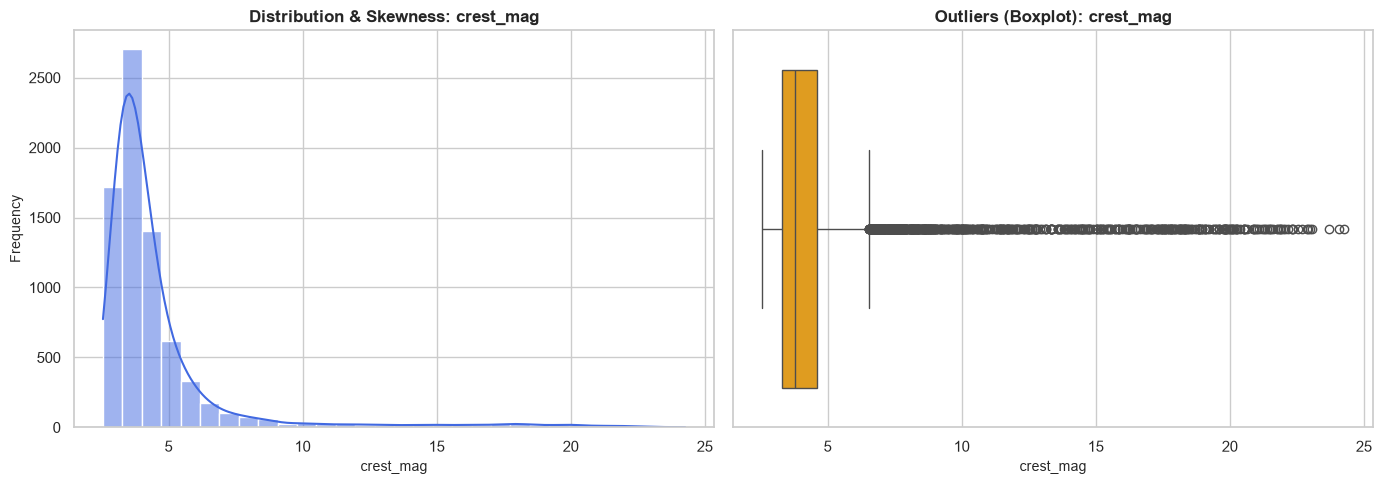

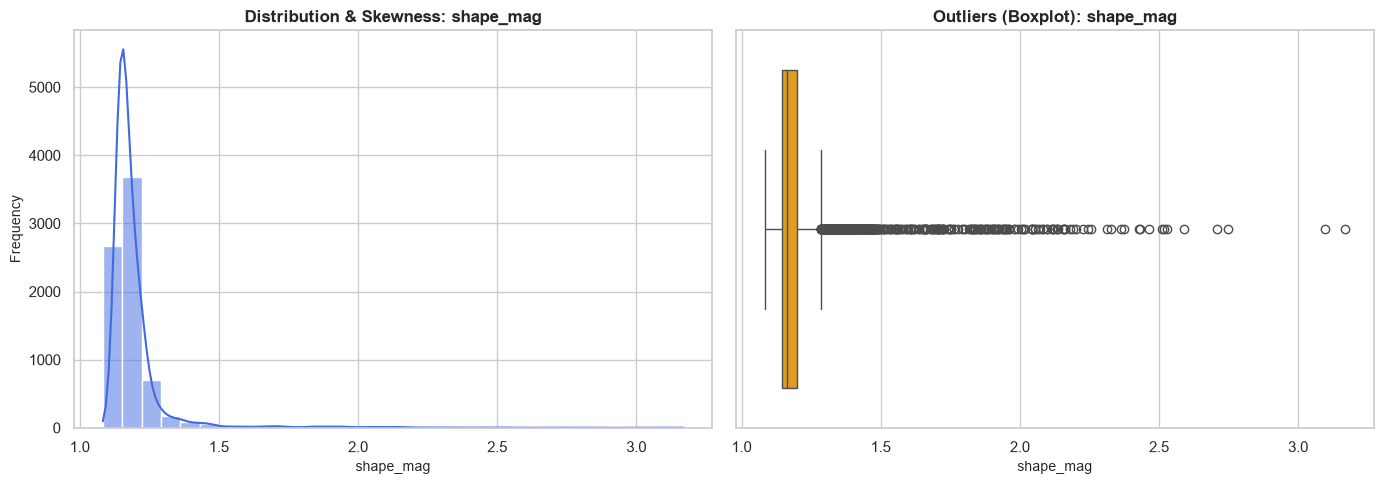

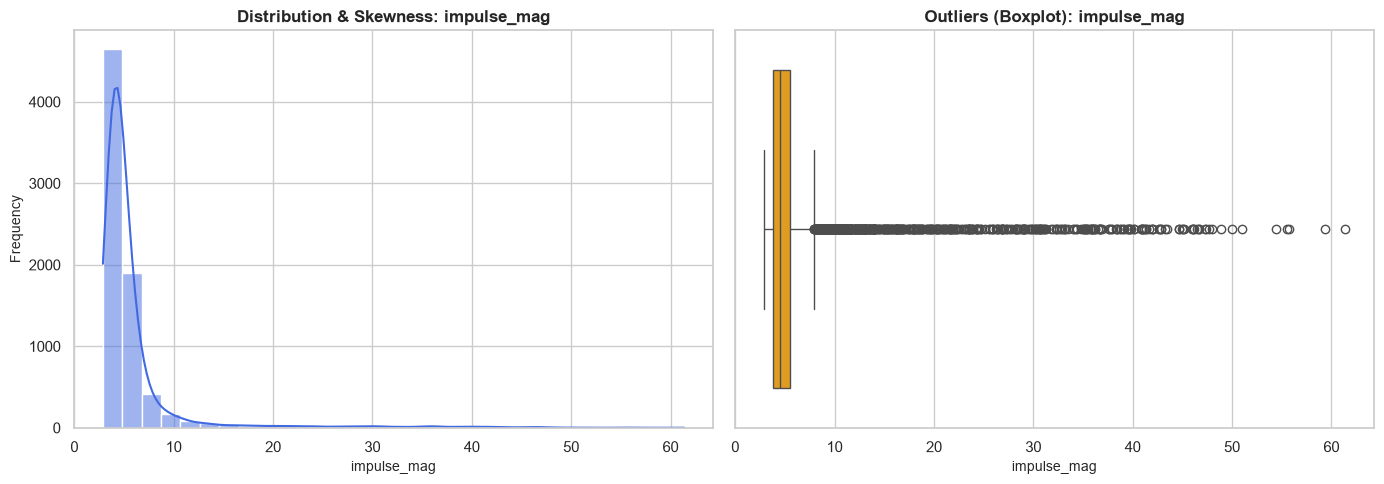

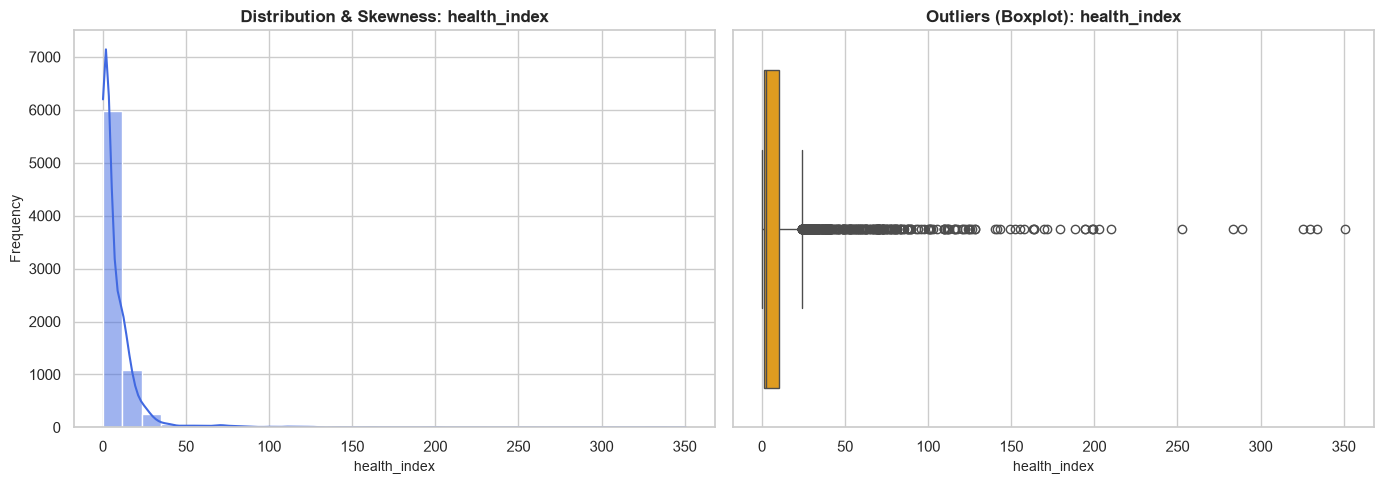

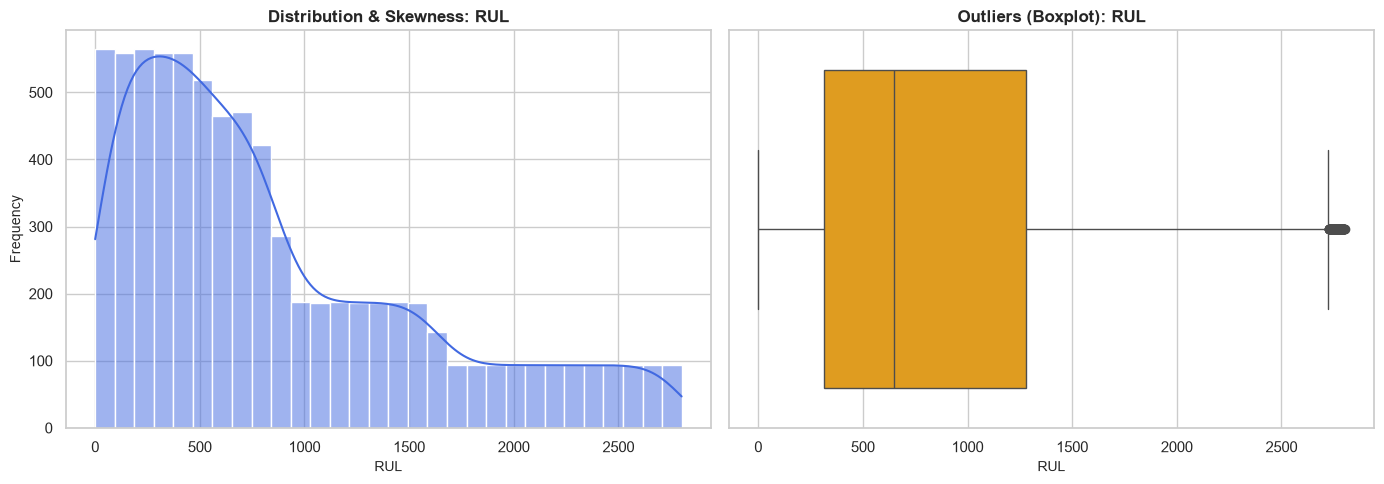

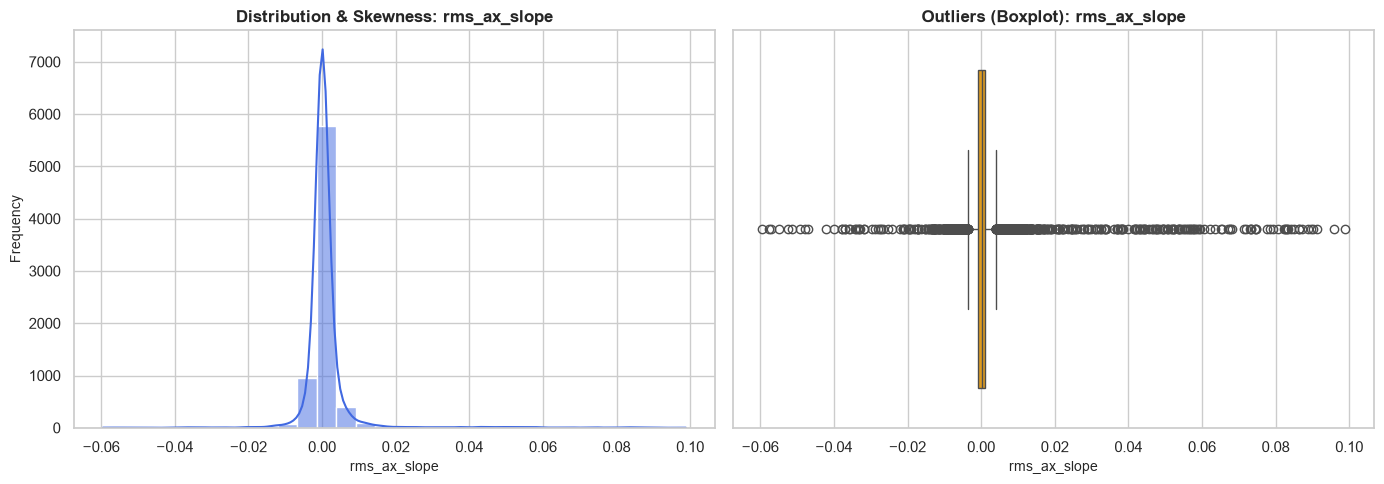

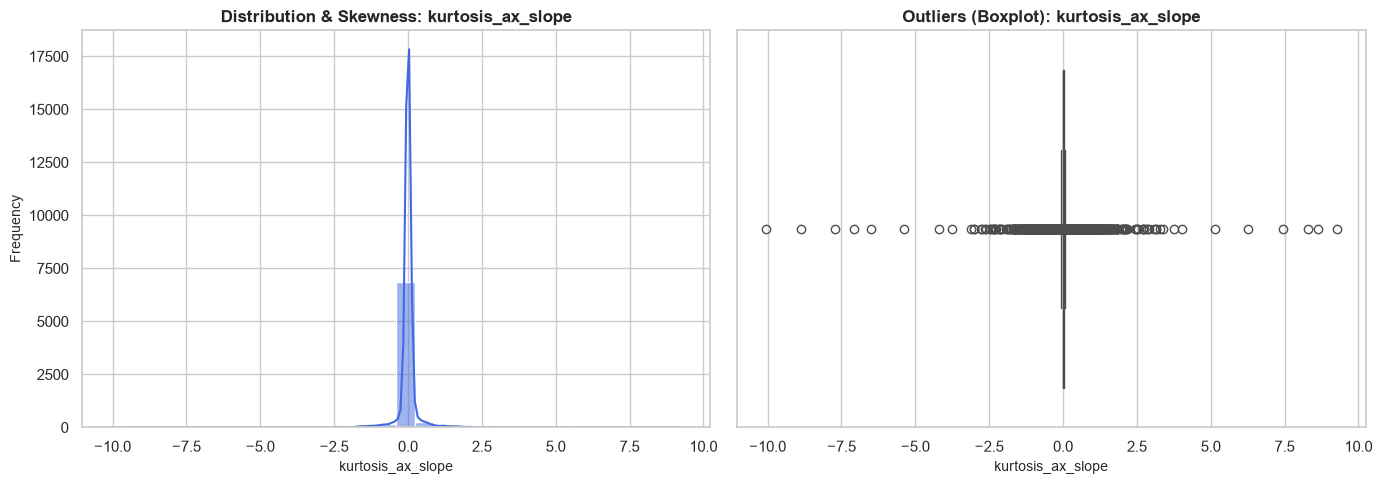

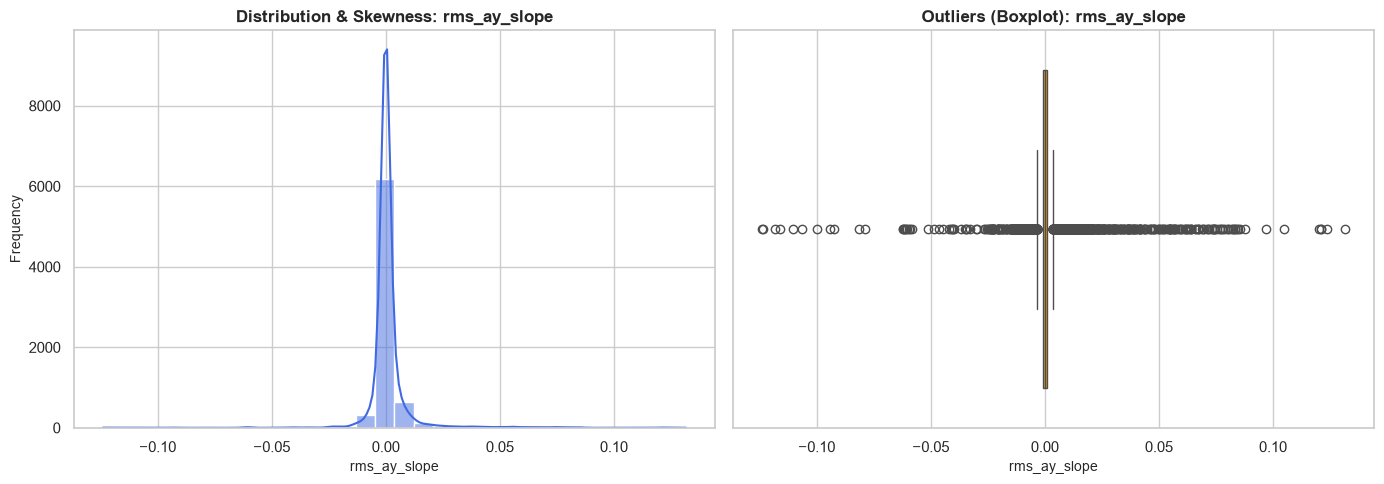

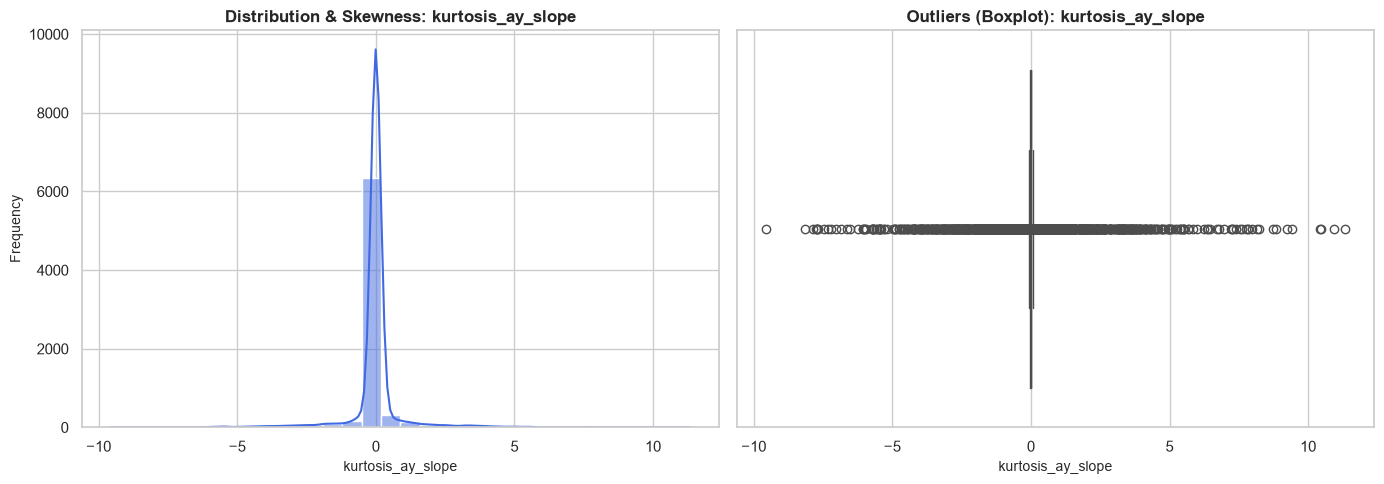

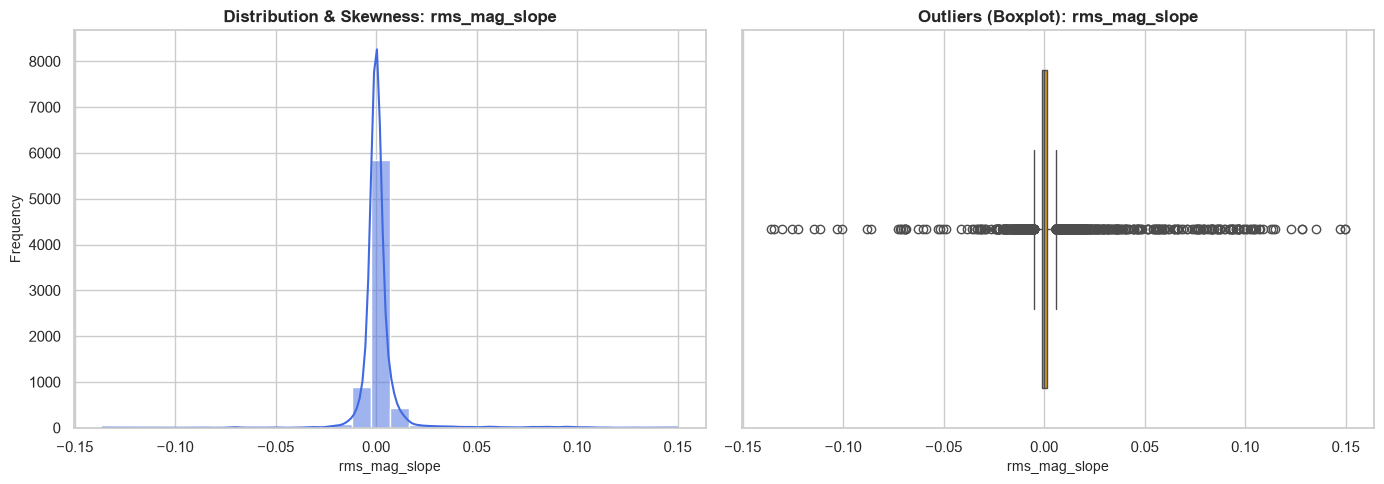

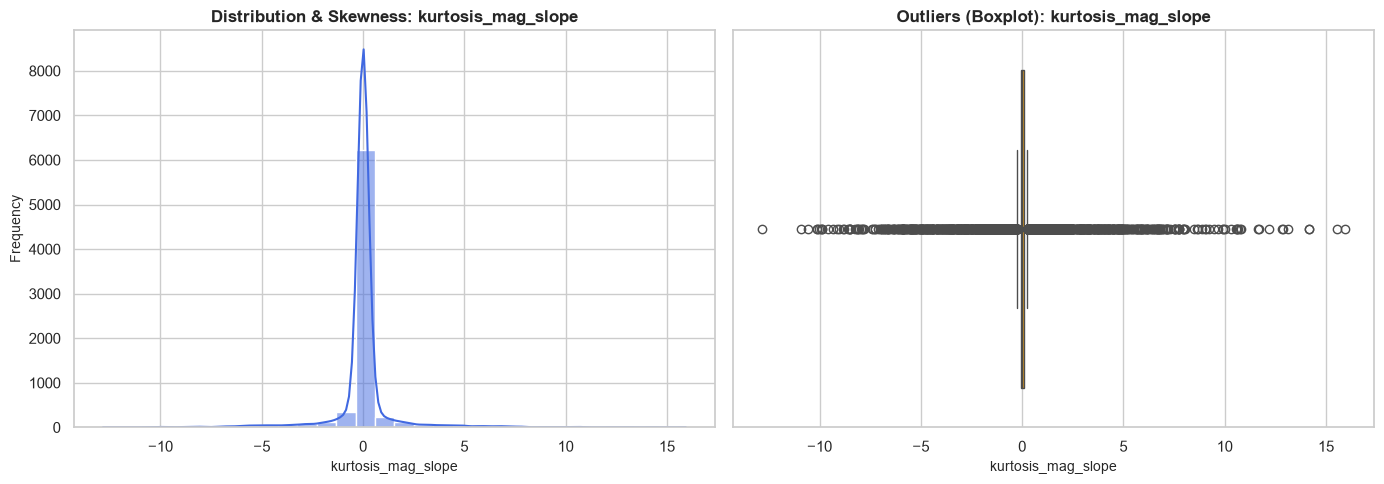

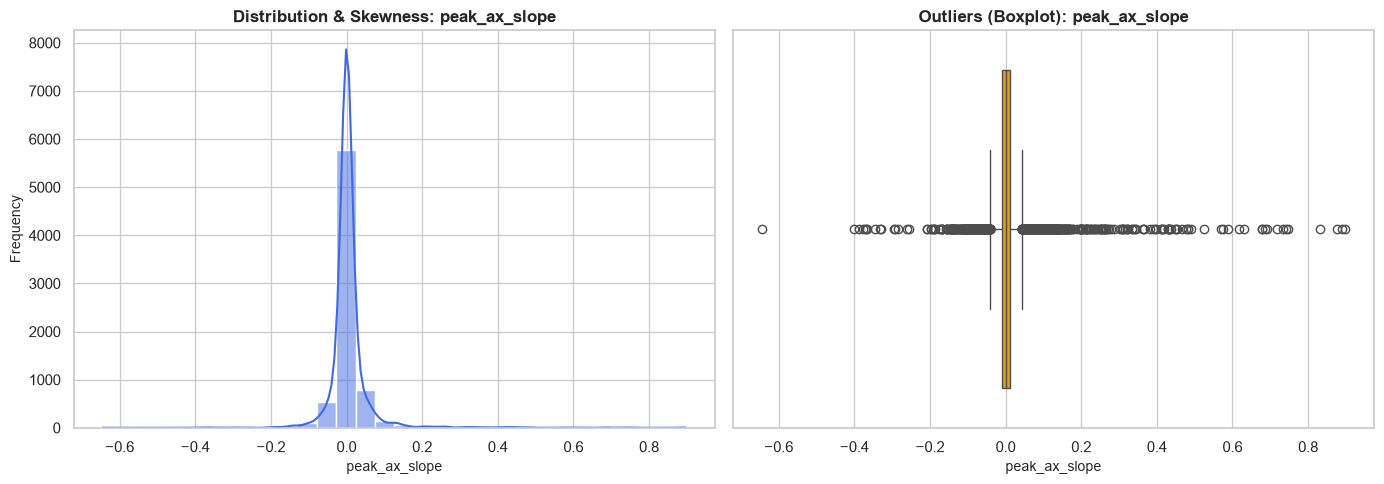

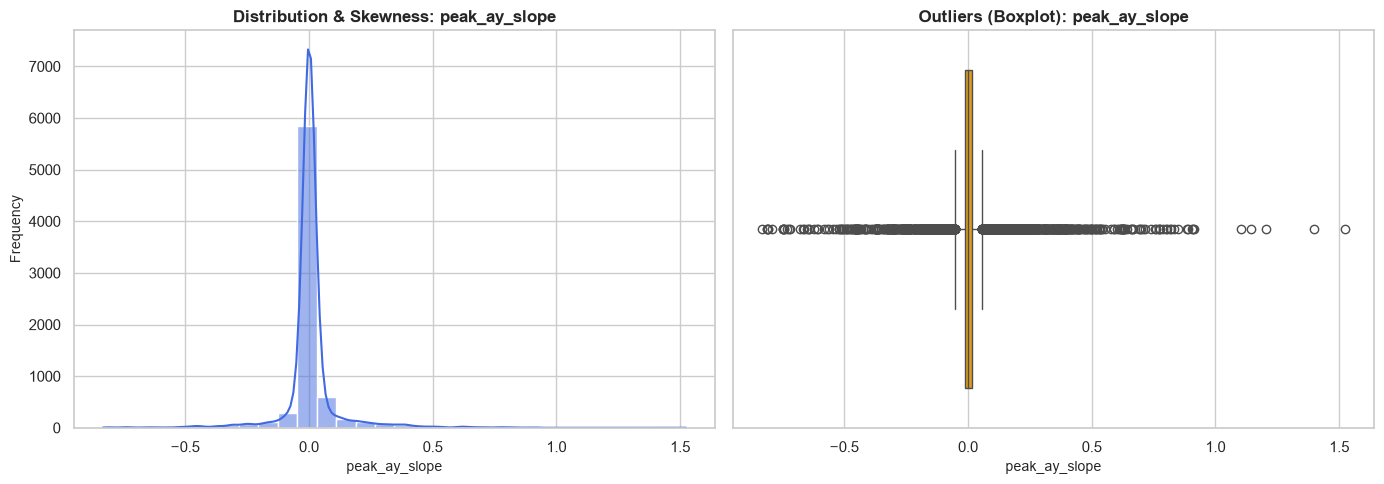

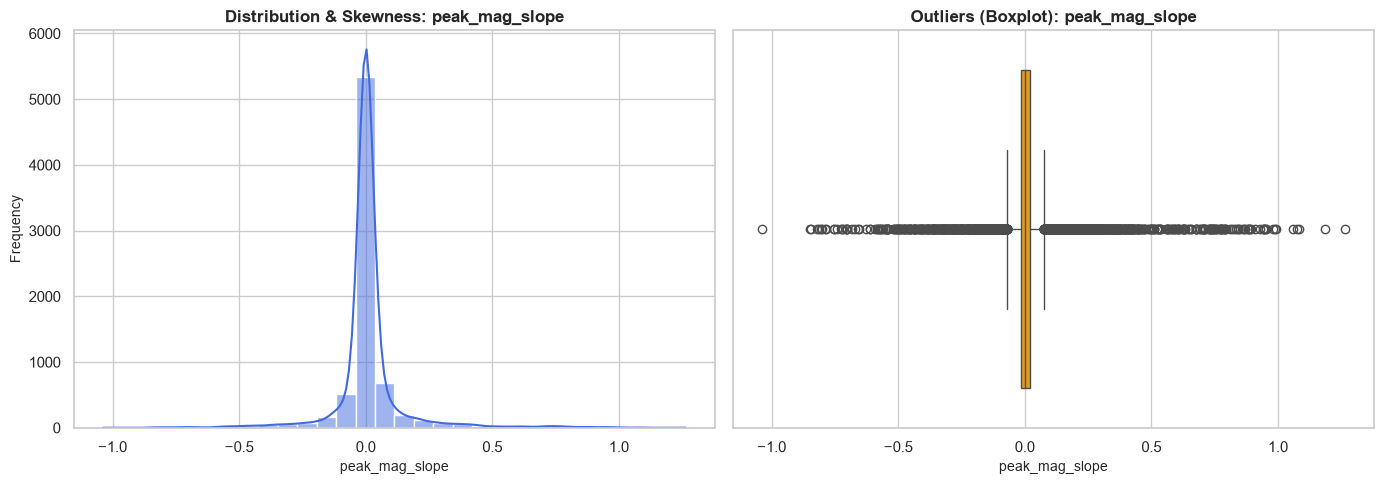

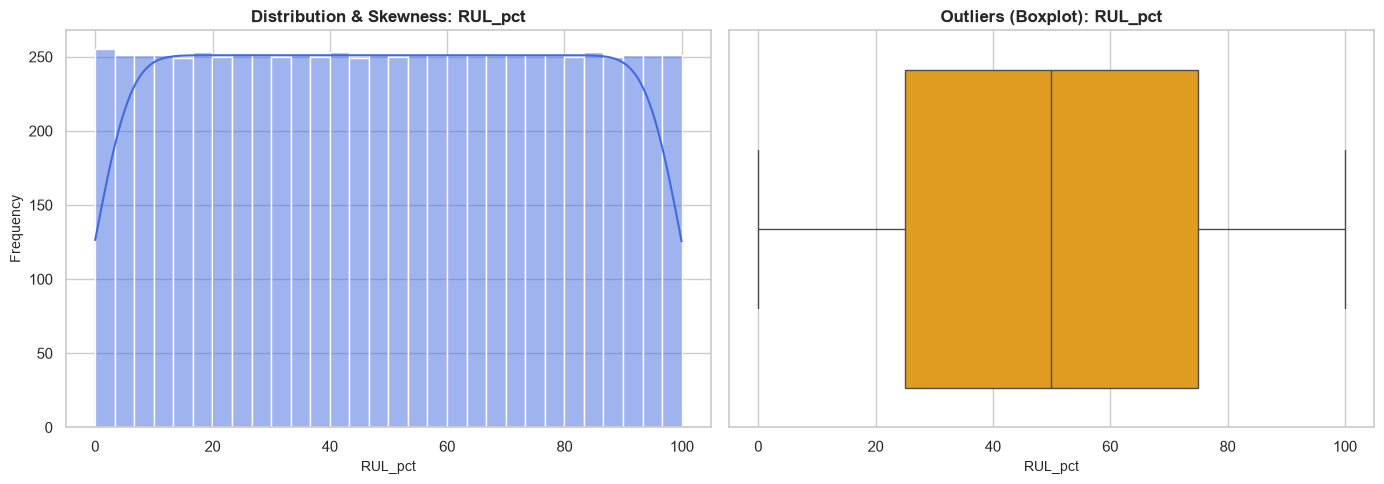

In [9]:
#detecting mean,std,skeweness and outliers for data preprocessing
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

# Sadece sayısal olan sütunları seçiyoruz (bearing_id veya step gibi metin/id'leri dışarıda bırakmak için)
numeric_cols = training_data_pd.select_dtypes(include=['number']).columns

# Her bir sayısal özellik için döngü oluşturuyoruz
for col in numeric_cols:
    plt.figure(figsize=(14, 5))
    
    # 1. Grafik: Histogram ve Yoğunluk Eğrisi (Dağılım ve Çarpıklık için)
    plt.subplot(1, 2, 1)
    sns.histplot(training_data_pd[col], kde=True, color='royalblue', bins=30)
    plt.title(f'Distribution & Skewness: {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Frequency', fontsize=10)
    
    # 2. Grafik: Boxplot (Aykırı Değerleri görmek için)
    plt.subplot(1, 2, 2)
    sns.boxplot(x=training_data_pd[col], color='orange')
    plt.title(f'Outliers (Boxplot): {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=10)
    
    plt.tight_layout()
    plt.show()

### Feature Selection

In [10]:
from sklearn import preprocessing
target_column = training_data_pd.pop("RUL_pct")

DROP_COLS = ["bearing_id", "step"]

feature_cols = [c for c in training_data_pd.columns if c not in DROP_COLS]
scaler = preprocessing.RobustScaler()

X_train_scaled = scaler.fit_transform(training_data_pd[feature_cols])


In [11]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_train_scaled_df.head(5)

,mean_ax,rms_ax,std_ax,skew_ax,kurtosis_ax,peak_ax,p2p_ax,crest_ax,shape_ax,impulse_ax,...,rms_ay_slope,kurtosis_ay_slope,rms_mag_slope,kurtosis_mag_slope,peak_ax_slope,peak_ay_slope,peak_mag_slope,regime_critical,regime_healthy,regime_transition
0,-0.079672,0.551596,0.552049,-1.440820,-0.148581,0.072185,0.255335,-0.645778,-0.140153,-0.579777,...,-0.029835,-0.008194,-0.045033,-0.002578,-0.050757,-0.041320,-0.041390,0.0,1.0,0.0
1,0.103269,0.440547,0.441102,-0.220060,-0.283086,0.240879,0.141006,-0.049819,-0.436527,-0.109001,...,7.579004,1.158712,-6.342657,-0.462176,10.253749,8.873345,-4.708678,0.0,1.0,0.0
2,-0.514122,0.564101,0.564343,0.864425,-0.384337,0.121616,0.065168,-0.558666,-0.362545,-0.532260,...,8.954267,-0.922021,4.073035,-2.665640,1.458975,4.471042,-3.837433,0.0,1.0,0.0
3,1.195903,0.472155,0.471029,0.162151,-0.350832,-0.058847,0.022485,-0.807107,-0.359436,-0.743756,...,10.164871,-0.347642,3.196678,-2.063806,-3.180449,4.460036,-3.203812,0.0,1.0,0.0
4,0.083721,0.373595,0.374236,0.378316,-0.433270,-0.109062,-0.070884,-0.754663,-0.474155,-0.712344,...,6.478553,-0.550528,-0.017752,-1.729418,-4.095873,3.821701,-3.217071,0.0,1.0,0.0


In [12]:
X_train_scaled_df = X_train_scaled_df.drop(columns=["RUL"])

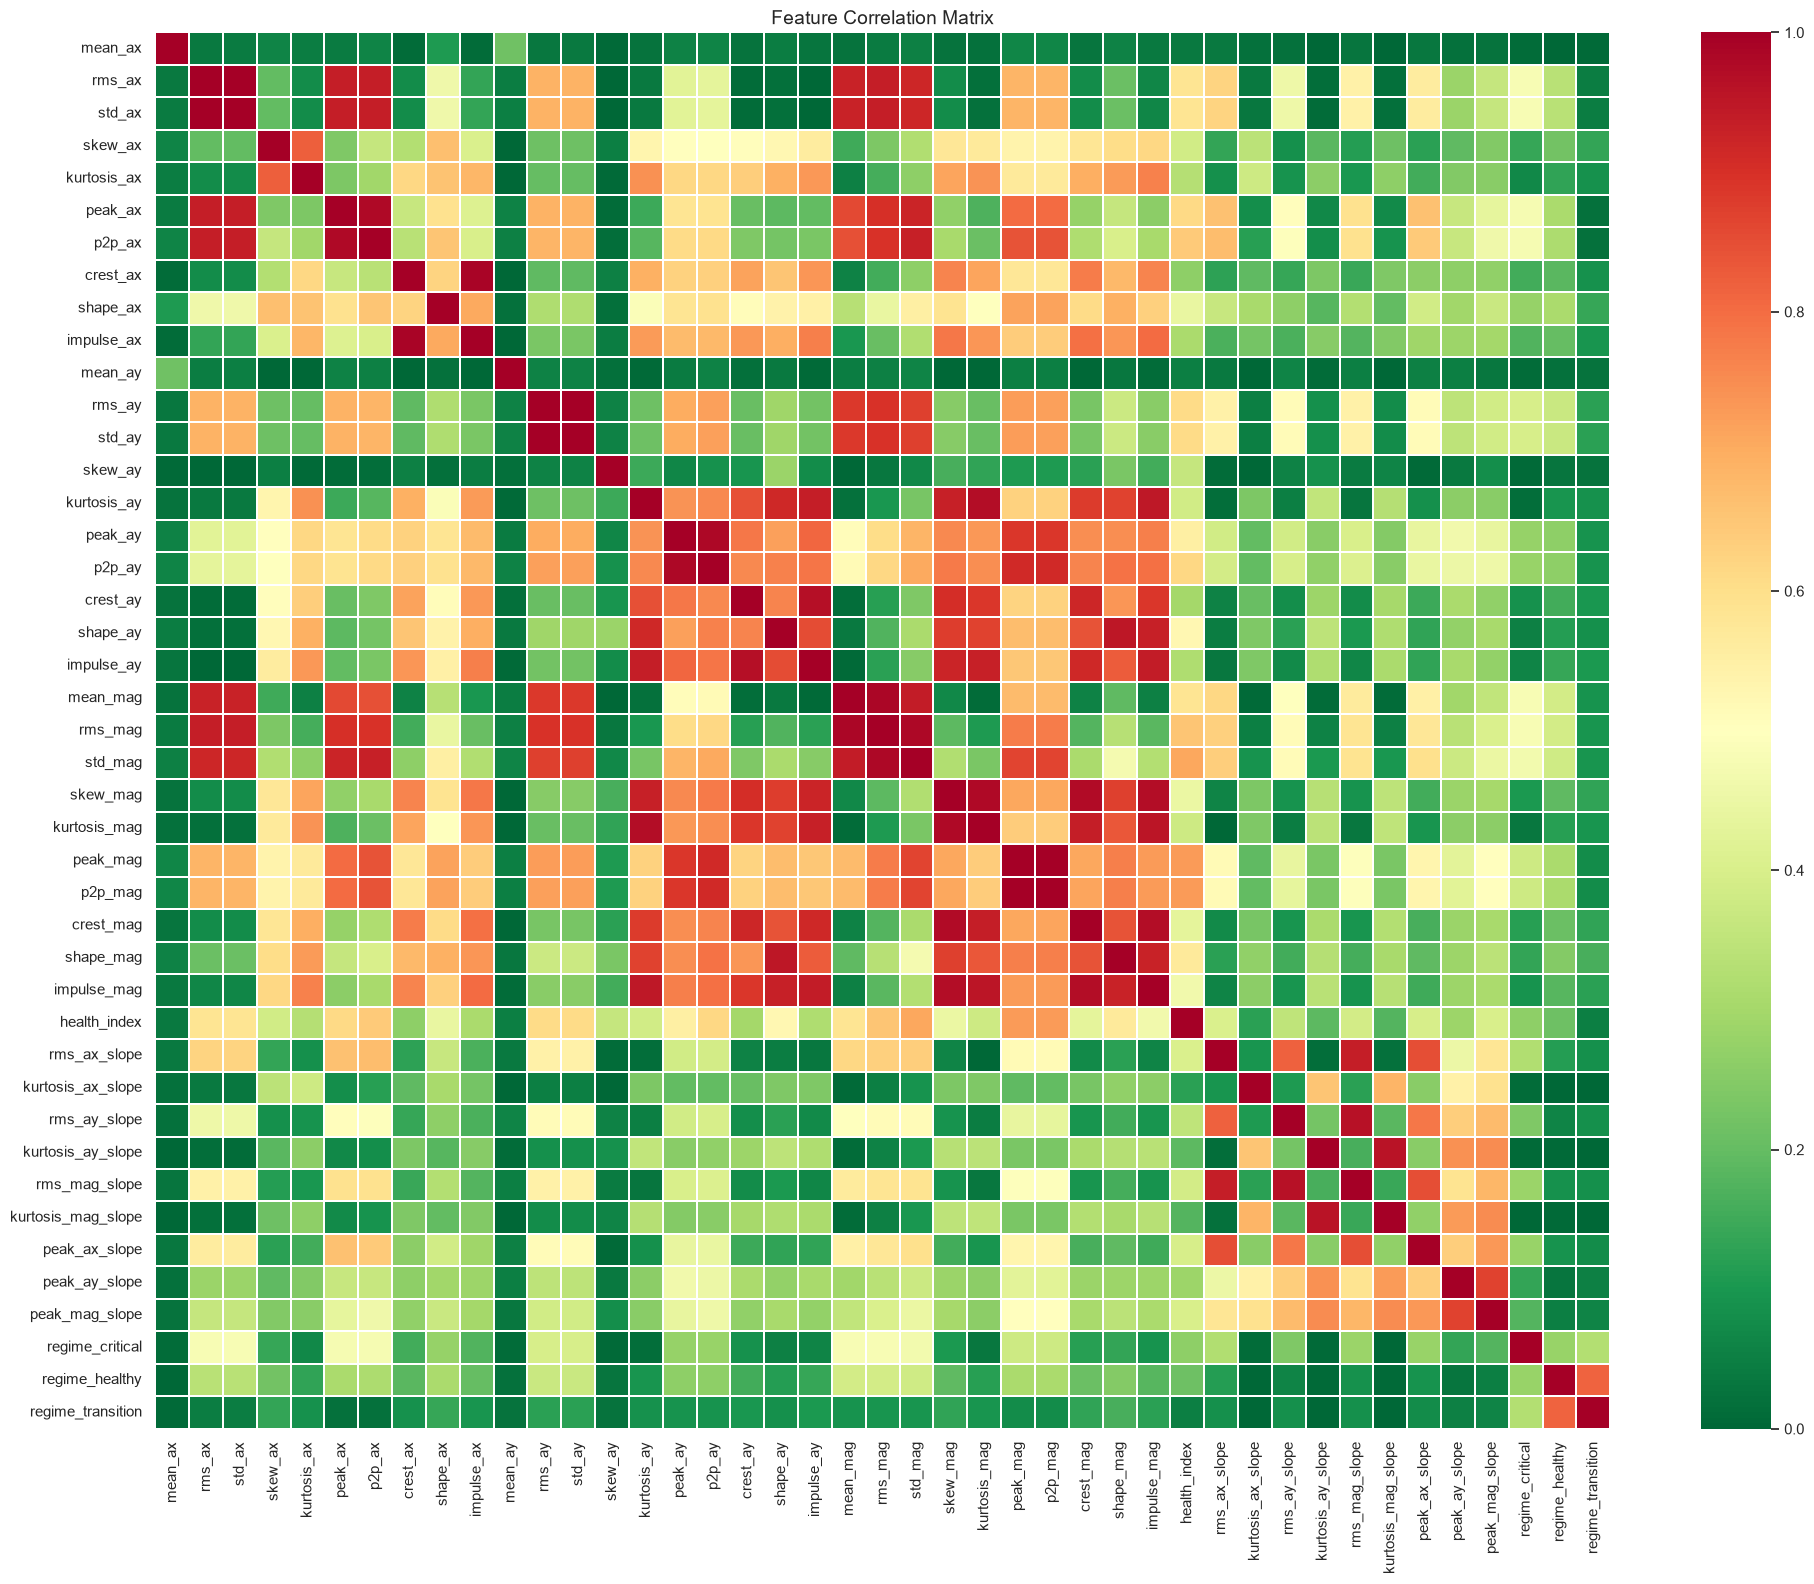

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = X_train_scaled_df.corr().abs()

plt.figure(figsize=(20, 16))
sns.heatmap(corr, 
            annot=False, 
            cmap='RdYlGn_r',
            vmin=0, vmax=1,
            linewidths=0.3)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
import numpy as np
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = (upper.stack()
             .reset_index()
             .rename(columns={'level_0': 'Feature_1', 'level_1': 'Feature_2', 0: 'correlation'})
             .sort_values('correlation', ascending=False))

print("=== High Correlation (> 0.90) ===")
print(high_corr[high_corr['correlation'] > 0.90].to_string(index=False))

print("\n=== Low Correlation (< 0.30) ===")
print(high_corr[high_corr['correlation'] < 0.30].head(20).to_string(index=False))

=== High Correlation (> 0.90) ===
        Feature_1          Feature_2  correlation
         peak_mag            p2p_mag     0.999998
           rms_ax             std_ax     0.999951
           rms_ay             std_ay     0.999951
         crest_ax         impulse_ax     0.988955
         mean_mag            rms_mag     0.986384
          peak_ay             p2p_ay     0.984324
          rms_mag            std_mag     0.981932
          peak_ax             p2p_ax     0.979569
         skew_mag       kurtosis_mag     0.977670
         skew_mag          crest_mag     0.974599
         skew_mag        impulse_mag     0.971577
        crest_mag        impulse_mag     0.970732
      kurtosis_ay       kurtosis_mag     0.969148
         crest_ay         impulse_ay     0.965966
     rms_ay_slope      rms_mag_slope     0.963387
kurtosis_ay_slope kurtosis_mag_slope     0.959585
     kurtosis_mag        impulse_mag     0.953947
         shape_ay          shape_mag     0.953076
      kurtosis_a

In [15]:
def drop_correlated(X, threshold=0.95):
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    print(f"Dropping {len(to_drop)} correlated features: {to_drop}")
    return X.drop(columns=to_drop)

X_result = drop_correlated(X_train_scaled_df, threshold=0.95)
print(f"Remaining features: {X_result.shape[1]}")

Dropping 15 correlated features: ['std_ax', 'p2p_ax', 'impulse_ax', 'std_ay', 'p2p_ay', 'impulse_ay', 'rms_mag', 'std_mag', 'kurtosis_mag', 'p2p_mag', 'crest_mag', 'shape_mag', 'impulse_mag', 'rms_mag_slope', 'kurtosis_mag_slope']
Remaining features: 28


In [16]:
from sklearn.feature_selection import mutual_info_regression
#mutual information regression to evaluate the relationship between features and the target variable
mi_scores = mutual_info_regression(X_result, target_column, random_state=42)

mi_df = pd.DataFrame({
    'Feature': X_result.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print(mi_df.to_string(index=False))

          Feature  MI_Score
         mean_mag  0.840083
           rms_ay  0.839821
           rms_ax  0.750379
     rms_ay_slope  0.440103
     health_index  0.438099
regime_transition  0.398749
     rms_ax_slope  0.397150
   regime_healthy  0.382780
kurtosis_ay_slope  0.355224
          peak_ax  0.351826
         peak_mag  0.343029
kurtosis_ax_slope  0.333174
  regime_critical  0.325903
          peak_ay  0.272601
   peak_mag_slope  0.270543
    peak_ay_slope  0.266949
    peak_ax_slope  0.261877
         skew_mag  0.253918
         shape_ax  0.247855
      kurtosis_ax  0.227562
      kurtosis_ay  0.135815
         shape_ay  0.132020
          skew_ax  0.122935
         crest_ax  0.066174
         crest_ay  0.064704
          skew_ay  0.045894
          mean_ay  0.032796
          mean_ax  0.009720


In [17]:
low_mi = mi_df[mi_df['MI_Score'] < 0.05]['Feature'].tolist()
print(f"Dropping: {low_mi}")

X_final = X_result.drop(columns=low_mi)
print(f"Remaining features: {X_final.shape[1]}")
print(X_final.columns.tolist())

Dropping: ['skew_ay', 'mean_ay', 'mean_ax']
Remaining features: 25
['rms_ax', 'skew_ax', 'kurtosis_ax', 'peak_ax', 'crest_ax', 'shape_ax', 'rms_ay', 'kurtosis_ay', 'peak_ay', 'crest_ay', 'shape_ay', 'mean_mag', 'skew_mag', 'peak_mag', 'health_index', 'rms_ax_slope', 'kurtosis_ax_slope', 'rms_ay_slope', 'kurtosis_ay_slope', 'peak_ax_slope', 'peak_ay_slope', 'peak_mag_slope', 'regime_critical', 'regime_healthy', 'regime_transition']


In [18]:
#baseline model and permutation importance implementation
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_final, target_column)

y_pred = rf.predict(X_final)
print(f"R²:   {r2_score(target_column, y_pred):.3f}")
print(f"MAE:  {mean_absolute_error(target_column, y_pred):.2f}")

R²:   0.989
MAE:  1.92


In [19]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf, X_final, target_column, n_repeats=10, random_state=42, n_jobs=-1)

perm_df = pd.DataFrame({
    'Feature': X_final.columns,
    'Importance': perm.importances_mean
}).sort_values('Importance', ascending=False)

print(perm_df.to_string(index=False))

          Feature  Importance
   regime_healthy    1.337282
           rms_ay    0.118256
           rms_ax    0.118236
         mean_mag    0.080495
regime_transition    0.079863
     health_index    0.071219
         shape_ax    0.062025
  regime_critical    0.054051
     rms_ay_slope    0.039742
      kurtosis_ax    0.021242
     rms_ax_slope    0.016199
      kurtosis_ay    0.013723
kurtosis_ay_slope    0.011034
kurtosis_ax_slope    0.010183
          skew_ax    0.010060
          peak_ax    0.007670
   peak_mag_slope    0.006866
         shape_ay    0.006781
         skew_mag    0.006418
         peak_mag    0.005898
    peak_ay_slope    0.004987
    peak_ax_slope    0.004545
          peak_ay    0.003969
         crest_ax    0.003610
         crest_ay    0.002305


In [20]:
low_perm = ['crest_ay', 'peak_ay', 'peak_ax_slope', 'crest_ax']
X_final = X_final.drop(columns=low_perm)
print(f"Final feature count: {X_final.shape[1]}")
print(X_final.columns.tolist())

Final feature count: 21
['rms_ax', 'skew_ax', 'kurtosis_ax', 'peak_ax', 'shape_ax', 'rms_ay', 'kurtosis_ay', 'shape_ay', 'mean_mag', 'skew_mag', 'peak_mag', 'health_index', 'rms_ax_slope', 'kurtosis_ax_slope', 'rms_ay_slope', 'kurtosis_ay_slope', 'peak_ay_slope', 'peak_mag_slope', 'regime_critical', 'regime_healthy', 'regime_transition']


In [23]:
type(X_final)

pandas.DataFrame

In [ ]:
import json

#download the features.json file
with open("features.json", "w") as final:
	json.dump(list(X_final.columns), final) 
 

In [29]:
import os
import joblib

output_dir = "C:\\Users\\elmaz\\AIProject\\NASA_Project\\src\\scaler"
os.makedirs(output_dir, exist_ok=True)
scaler_path = os.path.join(output_dir, "robust_scaler.pkl")
joblib.dump(scaler, scaler_path)

['C:\\Users\\elmaz\\AIProject\\NASA_Project\\src\\scaler\\robust_scaler.pkl']